# Ensemble analysis of the Monte Carlo v4 scenarios

This analysis brings together four campaigns with 10,000 trials each, combining Scenarios 1 and 2 with the Super Gaussian and Bastankhah wake models with the park of interest England Wind, referred to as `self` in the rest of the notebook, and to the self AEP and wake loss, this analysis includes the combined AEP of all active farms in the scenario, so it is possible to look at the self production and the energy growth of the whole world at the same time. The idea here is to understand how the scenarios change the results and how the two wake models respond to the same sampled worlds.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

RESULTS = Path("../../results")
COLOR_S1 = "#2a78d6"   # scenario 1 -->> categorical slot 1
COLOR_S2 = "#eb6834"   # scenario 2 --> categorical slot 2
COLOR_SG = "#2a78d6"   # Wake Model: SuperGaussian -- same slot 1, reused for model identity in Phase 4
COLOR_BK = "#eb6834"   # Wake Model: Bastankhah -- same slot 2, reused for model identity in Phase 4
COLOR_NEUTRAL = "#52514e"

## Data structure and model comparison

Each branch contains the `trials``, `arrivals`, and `segments` tables, as in the previous analysis. The difference now is that the same scenarios are simulated with two wake models, so the comparison cann separate the effect of the scenario construction from the effect of the model used to calculate wakes. For each branch, the last segment is used as the main comparison point, with one final row per trial. the final table also includes the mean density of the farms that received a target density within each sampled world.

In [2]:
def load_branch(scenario, run_id):
    d = RESULTS / scenario / run_id / "merged"
    return (pd.read_parquet(d / "trials.parquet"),
            pd.read_parquet(d / "arrivals.parquet"),
            pd.read_parquet(d / "segments.parquet"))

trials_s1_sg, arrivals_s1_sg, segments_s1_sg = load_branch("scenario_1", "production_10k_s1_supergaussian")
trials_s1_bk, arrivals_s1_bk, segments_s1_bk = load_branch("scenario_1", "production_10k_s1_bastankhah")
trials_s2_sg, arrivals_s2_sg, segments_s2_sg = load_branch("scenario_2", "production_10k_s2_supergaussian")
trials_s2_bk, arrivals_s2_bk, segments_s2_bk = load_branch("scenario_2", "production_10k_s2_bastankhah")

In [3]:
# one row per trial, taken at the final 5-year checkpoint (lifetime/final state) -- same checkpoint grid everywhere
FINAL_SEGMENT = segments_s1_sg["segment_id"].max()
FINAL_SEGMENT

np.int64(4)

Density is still aggregated by trial, meaning the average of the target densities of the farms that received this draw. This average does not represent the density of a specific farm, but it helps describe the average level of build-out in each world. Since the wake models do not take part in generating the scenarios, density, arrival, turbine, and geometry values need to be the same between Super Gaussian and Bastankhah when the seed and scenario are the same.

In [ ]:
def trial_density(arrivals):
    return arrivals.dropna(subset=["rho_target_mw_km2"]).groupby("trial_id")["rho_target_mw_km2"].mean().rename("mean_density_mw_km2")

def final_table(trials, segments, arrivals):
    return (segments[segments.segment_id == FINAL_SEGMENT]
            .merge(trials, on="trial_id")
            .merge(trial_density(arrivals), on="trial_id", how="left"))

# def final_table(trials, segments, arrivals):
#     return (segments[segments.segment_id == FINAL_SEGMENT]
#             .merge(TRIALS, on="trial_id")
#   
# 
#           

final_s1_sg = final_table(trials_s1_sg, segments_s1_sg, arrivals_s1_sg)
final_s1_bk = final_table(trials_s1_bk, segments_s1_bk, arrivals_s1_bk)
final_s2_sg = final_table(trials_s2_sg, segments_s2_sg, arrivals_s2_sg)
final_s2_bk = final_table(trials_s2_bk, segments_s2_bk, arrivals_s2_bk)
final_s1_sg.shape, final_s1_bk.shape, final_s2_sg.shape, final_s2_bk.shape

((10000, 29), (10000, 29), (10000, 29), (10000, 29))

## Plot conventions

The histograms show how each result is distributed across the 10,000 trials. P10, P50, and P90 represent the 10th, 50th, and 90th percentiles, with P50 being the median. The convergence plots show how these percentiles stabilize as more trials are included, repeating the trial order with different shuffles to show whether the final value depends strongly on sample order. In the time plots, the line is the median at each checkpoint and the band shows P10 to P90.

### Plot Helpers

In [ ]:
def hist_with_percentiles(data, color, xlabel, ylabel, title, bins=40, qs=(10, 50, 90)):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.hist(data, bins=bins, color=color, alpha=0.85, edgecolor="white", linewidth=0.3)
    ymax = ax.get_ylim()[1]
    for q in qs:
        v = np.percentile(data, q)
        ax.axvline(v, color=COLOR_NEUTRAL, linestyle="--", linewidth=1)
        ax.text(v, ymax, f"P{q}", rotation=90, va="top", ha="right", fontsize=8, color=COLOR_NEUTRAL)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def convergence_bands(data, color, ylabel, title, n_shuffles=8, n_points=50, qs=(10, 50, 90)):
    # running P10/P50/P90 as more trials are included, shuffled n_shuffles times -- the spread
    # across shuffles at a given N is the Monte Carlo sampling-order uncertainty at that sample size
    data = np.asarray(data)
    n = len(data)
    grid = np.unique(np.linspace(200, n, n_points).astype(int))
    rng = np.random.default_rng(0)
    tracks = {q: np.empty((n_shuffles, len(grid))) for q in qs}
    for s in range(n_shuffles):
        shuffled = rng.permutation(data)
        for gi, g in enumerate(grid):
            window = shuffled[:g]
            for q in qs:
                tracks[q][s, gi] = np.percentile(window, q)
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    for q in qs:
        band = tracks[q]
        med = band.mean(axis=0)
        ax.fill_between(grid, band.min(axis=0), band.max(axis=0), color=color, alpha=0.15)
        ax.plot(grid, med, color=color, linewidth=1.8 if q == 50 else 1, linestyle="-" if q == 50 else "--")
        ax.annotate(f"P{q}", (grid[-1], med[-1]), xytext=(4, 0), textcoords="offset points",
                    fontsize=8, color=COLOR_NEUTRAL, va="center")
    ax.set_xlabel("Trials (Samples)"); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def segment_trajectory(segments, color, ylabel, title, value_col):
    grouped = segments.groupby("start_year")[value_col]
    p10, p50, p90 = grouped.quantile(0.10), grouped.quantile(0.50), grouped.quantile(0.90)
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.fill_between(p50.index, p10, p90, color=color, alpha=0.2, label="P10-P90")
    ax.plot(p50.index, p50, color=color, linewidth=2, marker="o", label="P50")
    ax.set_xlabel("Simulation Year"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

def binned_line_plot(x, y, color, xlabel, ylabel, title):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.plot(x, y, color=color, linewidth=2, marker="o", markersize=4)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def overlay_hist(data_a, label_a, color_a, data_b, label_b, color_b, xlabel, ylabel, title, bins=40):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.hist(data_a, bins=bins, color=color_a, alpha=0.5, label=label_a)
    ax.hist(data_b, bins=bins, color=color_b, alpha=0.5, label=label_b)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

# def overlay_hist(data_a, label_a, color_a, data_b, label_b, color_b, xlabel): # MISSIng, correction above
#     fig, ax = plt.subplots(figsize=(6.5, 3.5))
#     ax.hist(data_a, bins=bins, color=color_a, alpha=0.5, label=label_a)
#     ax.hist(data_b, bins=bins, color=color_b, alpha=0.5, label=label_b)
#     ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
#     ax.legend(frameon=True, fontsize=12)
#     fig.tight_layout()
#     return fig, ax

def overlay_trajectory(segments_a, label_a, color_a, segments_b, label_b, color_b, ylabel, title, value_col):
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    for segments, label, color in [(segments_a, label_a, color_a), (segments_b, label_b, color_b)]:
        grouped = segments.groupby("start_year")[value_col]
        p10, p50, p90 = grouped.quantile(0.10), grouped.quantile(0.50), grouped.quantile(0.90)
        ax.fill_between(p50.index, p10, p90, color=color, alpha=0.15)
        ax.plot(p50.index, p50, color=color, linewidth=2, marker="o", label=label)
    ax.set_xlabel("Simulation Year"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax

## Scenario 1, Super Gaussian model

Scenario 1 starts with the real farms and the self as a reference, while the rest of the development appears over the horizon through speculative farms. This first section presents the full analysis for one of the models, including the new combined AEP variable for the scenario. In the following sections, when the same scenario is run with Bastankhah or when Scenario 2 is analyzed, the comments will be shorter and focused only on what changed.

## Scenario 1 -- Real farms + isolated self -- Wake Model: SuperGaussian

### Phase 1 -- Ingestion, Audit & Correlation Screening

### Initial audit

The campaign has 10,000 complete trials, 50,000 time records because each trial has five checkpoints, and 222,434 records in the `arrivals` table because each world contains several farms. Missing values in `arrivals` are expected because not all farms receive a target density, especially farms that already have a real layout or fixed parameters.

In [6]:
trials_s1_sg.shape, arrivals_s1_sg.shape, segments_s1_sg.shape

((10000, 13), (222434, 9), (50000, 16))

In [7]:
trials_s1_sg.isna().sum().sum(), arrivals_s1_sg.isna().sum().sum(), segments_s1_sg.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [8]:
trials_s1_sg.trial_id.nunique(), segments_s1_sg.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

### Input Uncertainty

### Sampled inputs

The climate controls remained centered on the mean wind rose, with mean rotation close to zero and speed and spread multipliers close to 1, as expected from the way the bootstrap was used. The mean density per trial was around 5.04 MW/km², with a median of 5.02 MW/km², remembering that this is an average across the farms inside each world and therefore varies less than the individual density. The number of speculative farms had a mean of 17.24, a median of 17, and ranged from 7 to 30, because the build-out follows the capacity target and may need more or fewer farms depending on the sampled area, density, and turbine.

In [9]:
trials_s1_sg[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,0.004905,1.000005,1.000182
std,1.451754,0.004794,0.025552
min,-3.935272,0.990664,0.941646
25%,-0.967548,0.996565,0.982683
50%,0.009613,1.000019,0.999843
75%,0.998158,1.003367,1.017706
max,3.935272,1.010155,1.070733


In [10]:
final_s1_sg['mean_density_mw_km2'].describe()

count    10000.000000
mean         5.044288
std          0.355881
min          3.871925
25%          4.792734
50%          5.022666
75%          5.276898
max          6.520006
Name: mean_density_mw_km2, dtype: float64

In [11]:
final_s1_sg['n_speculative'].describe()

count    10000.000000
mean        17.243400
std          3.144987
min          7.000000
25%         15.000000
50%         17.000000
75%         19.000000
max         30.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

### Association between inputs and energy

The correlations are now calculated for two responses, the active AEP of the self and the combined AEP of the whole scenario. The self AEP shows how the park responds to climate and wakes from neighboring farms, while the combined AEP shows how much energy the whole world produces when all active farms are added together. These correlations are an exploratory reading, not proof of causality, because capacity, turbine count, number of farms, and geometry are part of the same sampled world and are related to each other.

In [12]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s1_sg = final_s1_sg[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s1_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.032470,0.003980
climate_speed_multiplier,0.386370,0.054226
climate_spread_multiplier,0.056959,-0.013295
n_speculative,-0.068187,0.071835
mean_density_mw_km2,0.027313,-0.050105
active_mw,-0.332289,0.991753
n_active_turbines,-0.316039,0.948182


In [13]:
spearman_s1_sg = final_s1_sg[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s1_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.040357,-0.001329
climate_speed_multiplier,0.419295,0.054134
climate_spread_multiplier,0.060515,-0.014899
n_speculative,-0.078114,0.057030
mean_density_mw_km2,0.036924,-0.044677
active_mw,-0.341014,0.991259
n_active_turbines,-0.326131,0.944266


in Super Gaussian, the active AEP of the self is most associated with the climate speed multiplier, with a correlation of 0.386, which makes sense because speed directly changes energy production. The combined AEP of the scenario is almost entirely associated with active capacity, with a correlation of 0.992, followed by the number of active turbines, with 0.948, and this was expected because the combined variable adds the energy from all farms, so a larger built system tends to produce more total energy. Capacity still does not explain everything on its own, since the result also depends on the sampled turbines, internal wakes, and climate in each trial.

In [14]:
pearson_s1_sg['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.386370
active_mw                   -0.332289
n_active_turbines           -0.316039
n_speculative               -0.068187
climate_spread_multiplier    0.056959
climate_rotation_deg         0.032470
mean_density_mw_km2          0.027313
Name: active_aep_gwh, dtype: float64

In [15]:
pearson_s1_sg['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.991753
n_active_turbines            0.948182
n_speculative                0.071835
climate_speed_multiplier     0.054226
mean_density_mw_km2         -0.050105
climate_spread_multiplier   -0.013295
climate_rotation_deg         0.003980
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

### Density, arrival, and scenario scale

Individual density still follows the distribution used for speculative build-out, with more concentration in the central range and a tail toward higher values, allowing denser farms without making them the most common case. Farm arrivals increase toward the end of the horizon, as defined by the accelerated time distribution, so together, thesee two choices mean that the final number of turbines is not fixed, and each trial ends with a different way.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

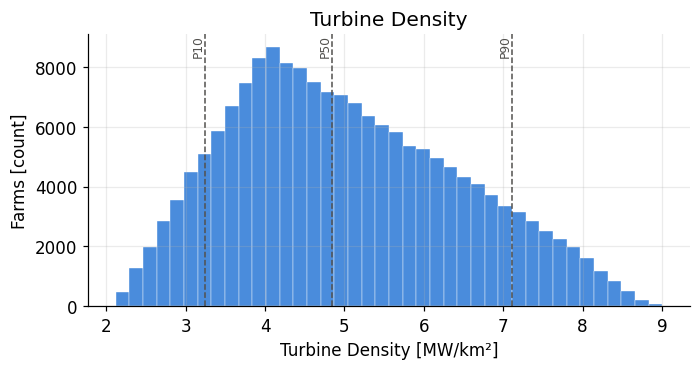

In [16]:
density = arrivals_s1_sg["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_SG, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

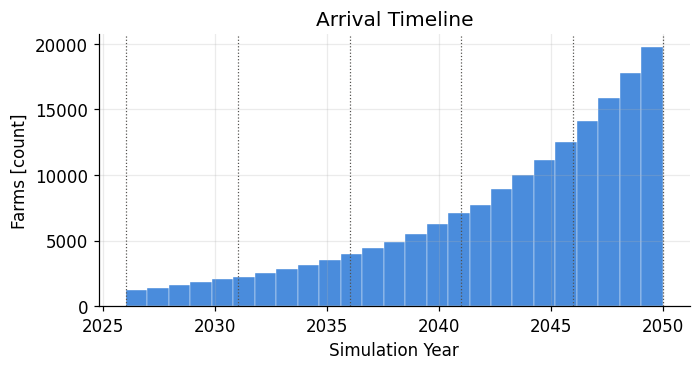

In [17]:
# only "speculative" farms draw a random arrival year -- self/real_layout/cluster_fixed are all fixed at YEAR_START
checkpoints = sorted(set(segments_s1_sg.start_year) | set(segments_s1_sg.end_year))
new_farm_years = arrivals_s1_sg.loc[arrivals_s1_sg.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_SG, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

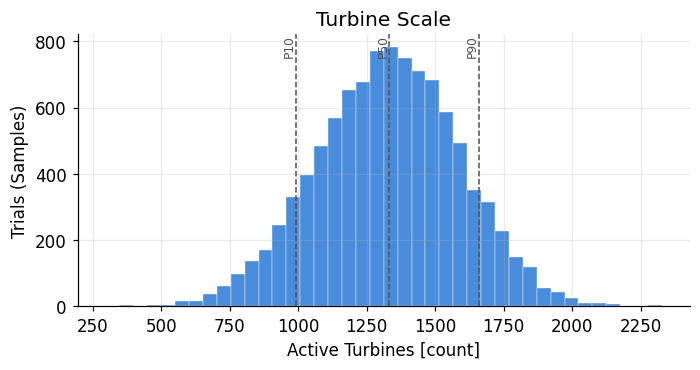

In [18]:
hist_with_percentiles(final_s1_sg["n_active_turbines"], COLOR_SG, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

### Self AEP

The active AEP of the self at the last checkpoint includes the effect of neighboring farms, which in Super Gaussian, the percentiles are approximately 3,049.2 GWh at P10, 3,134.5 GWh at the median, and 3,187.9 GWh at P90. This range appears because of the sampled climate.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

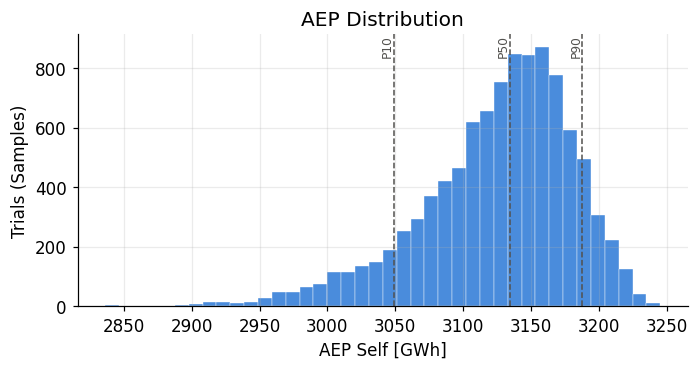

In [19]:
hist_with_percentiles(final_s1_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

### Combined AEP of the scenario

The combined AEP adds the production of all active turbines at the last checkpoint, so it should not be interpreted as the energy of the self. It shows the energy scale of the world created in each trial. In Scenario 1 with Super Gaussian, P10 is approximately 56.0 TWh, the median is 74.6 TWh, and P90 is 91.5 TWh, this range is much wider than the self AEP range because the result now includes all variation in capacity and turbine count across the scenario.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

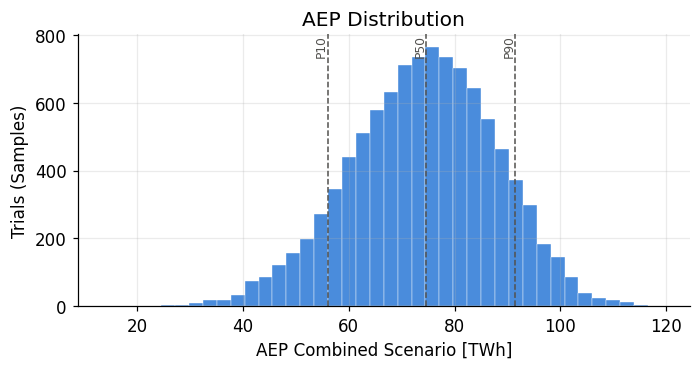

In [20]:
hist_with_percentiles(final_s1_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

### Wake loss of the self

Wake loss in Scenario 1 with Super Gaussian has a median of 3.59%, a P10 of 2.25%, and a P90 of 6.12%. The distribution has a tail toward higher values, so there is a group of worlds where the self is more exposed to wakes because of the combination of build-out, farm locations, and the time when they enter the scenario.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

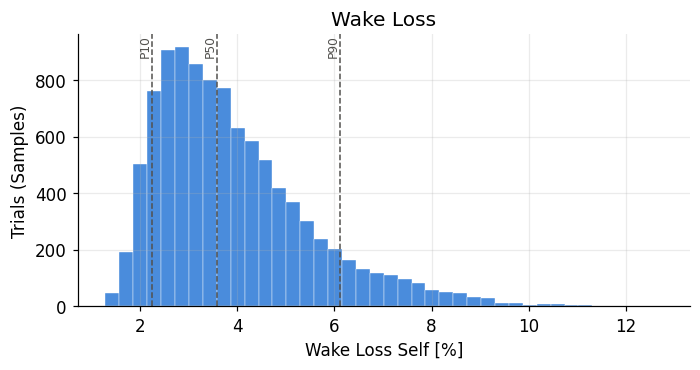

In [21]:
hist_with_percentiles(final_s1_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

In [22]:
np.percentile(final_s1_sg['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([3049.22625324, 3134.53897075, 3187.92954624])

The convergence plots check whether the percentiles used to summarize risk are already stable with 10,000 trials. The lines show P10, P50, and P90 calculated with a growing number of samples, and the bands show variation caused by the order in which trials enter. When the lines become nearly stable at the end, this indicates that the campaign is already estimating these percentiles consistently for this model and scenario.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

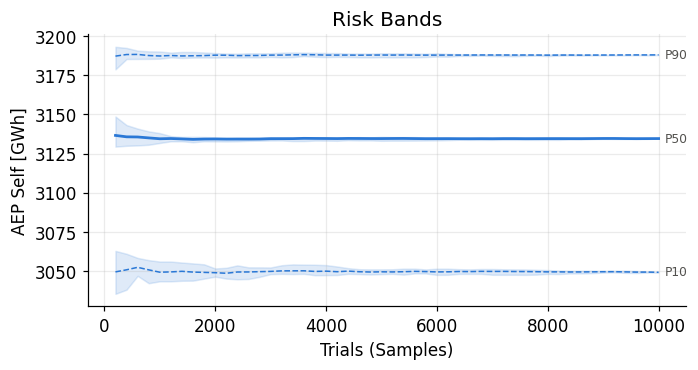

In [23]:
convergence_bands(final_s1_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Risk Bands")

In [24]:
np.percentile(final_s1_sg['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([56.04460266, 74.63505835, 91.45651299])

The same check is done here for combined AEP. Since this variable responds strongly to the total built capacity, it has a wider range between P10 and P90, but the plot shows whether this range and its percentiles keep changing as new trials are included or have already stabilized.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

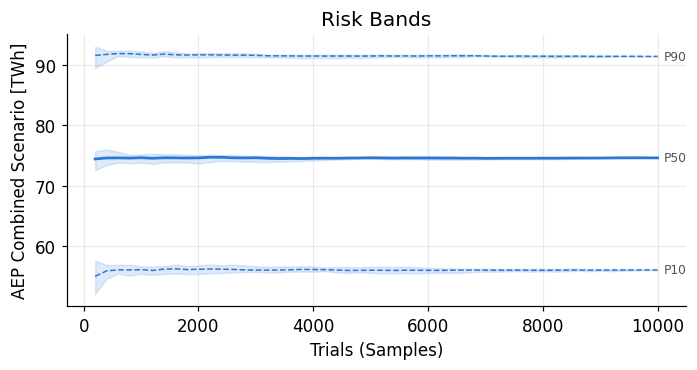

In [25]:
convergence_bands(final_s1_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Risk Bands")

In [26]:
np.percentile(final_s1_sg['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([2.25172665, 3.59054121, 6.12176058])

For wake loss, convergence is especially important for the tail percentiles. The median shows the most common result, but P90 represents the worlds with higher exposure, so the stability of this value helps use the campaign as a basis for a risk reading rather than only an average-value reading.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

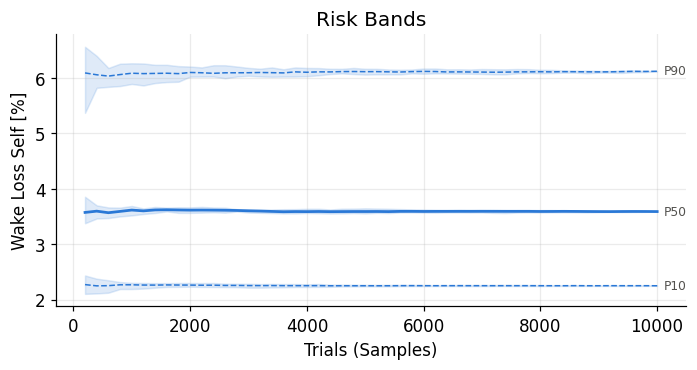

In [27]:
convergence_bands(final_s1_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Risk Bands")

### Time evolution of wake loss

Median wake loss increases through Scenario 1 because more farms enter operation over time. The P10 to P90 band also opens toward the end of the horizon, showing that the worlds become more different from each other as density, capacity, location, and arrival decisions accumulate.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

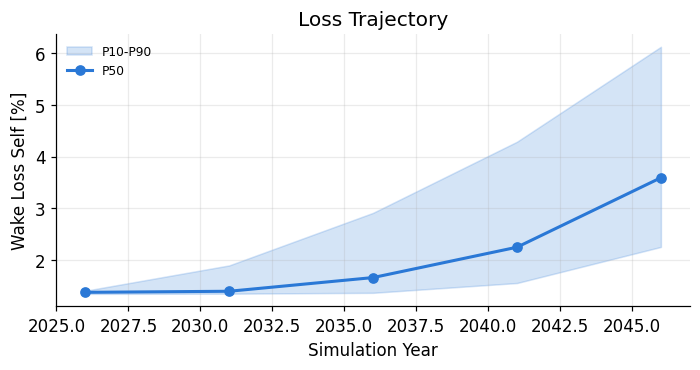

In [28]:
segment_trajectory(segments_s1_sg, COLOR_SG, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

Combined AEP grows over time because the scenario adds farms and active capacity. This plot is important together with the wake loss plot because it shows the main trade-off in the study: the world produces more total energy as it develops, but this same growth can increase the self exposure to wakes.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

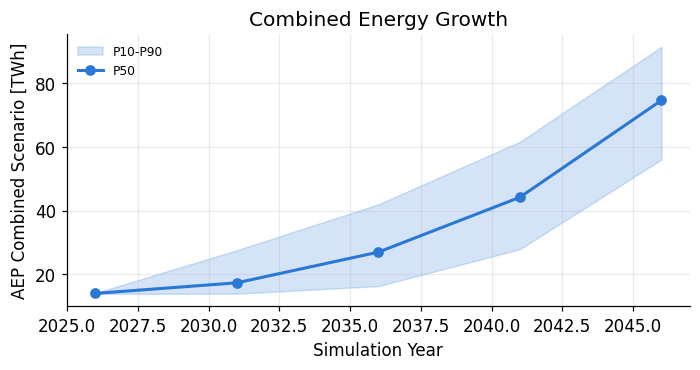

In [29]:
segments_s1_sg["world_aep_twh"] = segments_s1_sg["world_aep_gwh"] / 1000
segment_trajectory(segments_s1_sg, COLOR_SG, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

## Combined energy and effect on the self

After looking at each distribution separately, this section brings together the combined energy of the scenario and the wake loss of the self. The question is not whether more total energy is bad, since the goal of offshore development is precisely to increase regional production. The question is how this scenario growth appears together with the relative loss of the self, and whether there is a point where expansion starts to affect this park more clearly.

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

In [30]:
final_s1_sg[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.36403129039748305)

In Scenario 1 with Super Gaussian, the correlation between combined AEP and wake loss is 0.364. This shows a moderate positive association: worlds that produce more total energy also tend to have higher wake loss at the self. But the spread of the points shows that total energy is not the only thing that matters, since two worlds with similar combined AEP can have different losses depending on where capacity was built and how the wakes align with the self.

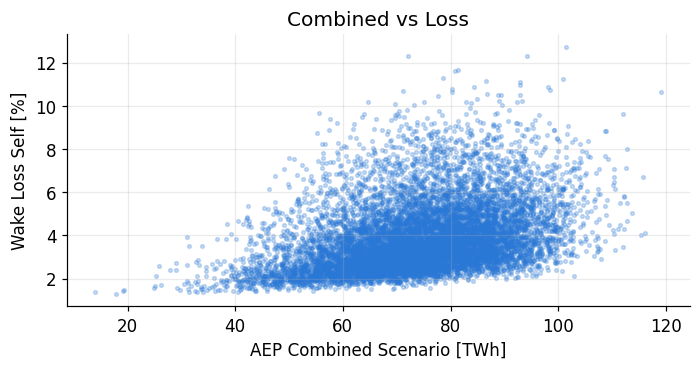

In [31]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s1_sg["world_aep_gwh"] / 1000, final_s1_sg["loss_pct"], s=6, alpha=0.25, color=COLOR_SG)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

To look at this relationship in a more organized way, the segments are separated into active-capacity bins. In each bin, mean capacity, mean combined AEP, and mean active AEP of the self are calculated. This avoids reading only individual points and helps show how the average response changes as the system becomes larger.

In [32]:
capacity_bins_s1_sg = segments_s1_sg.copy()
capacity_bins_s1_sg["capacity_bin"] = pd.qcut(capacity_bins_s1_sg["active_mw"], 20, duplicates="drop")
sat_table_s1_sg = capacity_bins_s1_sg.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s1_sg

,active_mw,world_aep_twh,active_aep_gwh
0,3612.766276,14.435230,3207.343222
1,5014.106856,19.814550,3200.951305
2,5770.765118,22.630024,3197.188046
3,6603.671068,25.656216,3192.063026
4,7560.538200,29.182113,3188.029220
5,8663.116200,33.202359,3183.344029
6,9888.961615,37.635964,3176.839840
7,11266.670868,42.691500,3170.440548
8,12888.420200,48.542055,3162.997019
9,14792.860600,55.470295,3150.875970


In [33]:
np.diff(sat_table_s1_sg['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 5.37931989,  2.81547331,  3.02619232,  3.52589736,  4.02024587,
        4.43360427,  5.05553683,  5.85055418,  6.92824066,  7.65662717,
        7.99851535,  8.13793679, 11.67293283])

Combined AEP increases continuously with active capacity, as expected, going from approximately 14.4 TWh in the lowest bin to 90.9 TWh in the highest bin. Saturation, which was not visible, the plot shows that more capacity continues to add energy to the scenario. 

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

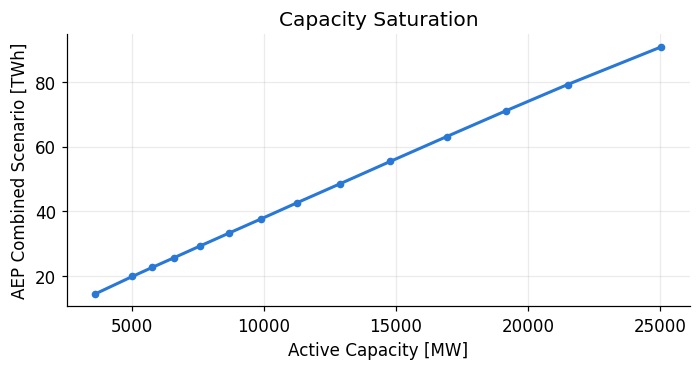

In [34]:
binned_line_plot(sat_table_s1_sg["active_mw"], sat_table_s1_sg["world_aep_twh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

While combined AEP grows with capacity, the self AEP decreases from approximately 3,207 GWh to 3,103 GWh between the lowest and highest active-capacity bins. This shows the relationship the scenario was designed to explore: the whole system gains energy with expansion, but the self can lose part of its active production because it is inside an environment with more wakes.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

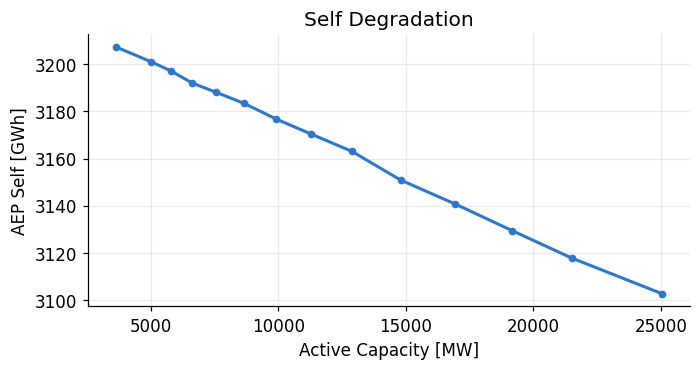

In [35]:
binned_line_plot(sat_table_s1_sg["active_mw"], sat_table_s1_sg["active_aep_gwh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

## Scenario 1, Bastankhah model

The same Scenario 1 is now evaluated with Bastankhah. The worlds are not generated again; only the wakes are recalculated with another model. For this reason, before comparing the energy results, it is important to confirm that the inputs and layouts are exactly the same as those used with Super Gaussian.

## Scenario 1 -- Real farms + isolated self -- Wake Model: Bastankhah

### Phase 1 -- Ingestion, Audit & Correlation Screening

The audit appears again with the same table sizes and no new missing values outside what was expected. More importantly, the test returns `True` for the columns that define each trial and for the arrivals table. This confirms that seed, climate, farm count, density, capacity, geometry, and schedule are the same between the two models, so the differences from this point forward are differences in the wake calculation, not different scenarios.

In [36]:
trials_s1_bk.shape, arrivals_s1_bk.shape, segments_s1_bk.shape

((10000, 13), (222434, 9), (50000, 16))

In [37]:
trials_s1_bk.isna().sum().sum(), arrivals_s1_bk.isna().sum().sum(), segments_s1_bk.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [38]:
trials_s1_bk.trial_id.nunique(), segments_s1_bk.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

In [39]:
# scenario generation never touches model_name (PIPELINE.md) -- trials/arrivals should be byte-identical to the SuperGaussian branch
cols = ["seed", "n_speculative", "fixed_capacity_mw", "climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier"]
trials_s1_bk[cols].equals(trials_s1_sg[cols]), arrivals_s1_bk.equals(arrivals_s1_sg)

(True, True)

### Input Uncertainty

The climate, mean-density, and farm-count statistics are the same as those seen with Super Gaussian, as expected, so there is no need to reinterpret these distributions here. What changes now are the responses calculated by the Bastankhah model for these same worlds.

In [40]:
trials_s1_bk[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,0.004905,1.000005,1.000182
std,1.451754,0.004794,0.025552
min,-3.935272,0.990664,0.941646
25%,-0.967548,0.996565,0.982683
50%,0.009613,1.000019,0.999843
75%,0.998158,1.003367,1.017706
max,3.935272,1.010155,1.070733


In [41]:
final_s1_bk['mean_density_mw_km2'].describe()

count    10000.000000
mean         5.044288
std          0.355881
min          3.871925
25%          4.792734
50%          5.022666
75%          5.276898
max          6.520006
Name: mean_density_mw_km2, dtype: float64

In [42]:
final_s1_bk['n_speculative'].describe()

count    10000.000000
mean        17.243400
std          3.144987
min          7.000000
25%         15.000000
50%         17.000000
75%         19.000000
max         30.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

The same general pattern appears here: combined AEP remains almost entirely associated with active capacity, with a correlation of 0.994, and turbine count, with 0.953. For the self AEP, the speed multiplier has an even stronger association, 0.547, while capacity and turbine count remain negatively associated because more development increases wake exposure. The values change, but the main reading stays the same: total energy follows system scale, and self energy responds to climate and the wake environment.

In [43]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s1_bk = final_s1_bk[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s1_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.033125,0.002214
climate_speed_multiplier,0.547363,0.051730
climate_spread_multiplier,0.064567,-0.014247
n_speculative,-0.050354,0.058917
mean_density_mw_km2,0.017663,-0.041147
active_mw,-0.289782,0.994465
n_active_turbines,-0.271472,0.952681


In [44]:
spearman_s1_bk = final_s1_bk[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s1_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.037118,-0.003146
climate_speed_multiplier,0.578717,0.051606
climate_spread_multiplier,0.065172,-0.015860
n_speculative,-0.057964,0.045174
mean_density_mw_km2,0.026376,-0.036489
active_mw,-0.285428,0.994134
n_active_turbines,-0.269456,0.949067


In [45]:
pearson_s1_bk['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.547363
active_mw                   -0.289782
n_active_turbines           -0.271472
climate_spread_multiplier    0.064567
n_speculative               -0.050354
climate_rotation_deg         0.033125
mean_density_mw_km2          0.017663
Name: active_aep_gwh, dtype: float64

In [46]:
pearson_s1_bk['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.994465
n_active_turbines            0.952681
n_speculative                0.058917
climate_speed_multiplier     0.051730
mean_density_mw_km2         -0.041147
climate_spread_multiplier   -0.014247
climate_rotation_deg         0.002214
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

Since scenario generation was confirmed to be the same, the density, arrival-year, and turbine-count distributions are the same as in the previous block. For this reason, the focus here is only on the energy and wake-loss results calculated by Bastankhah.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

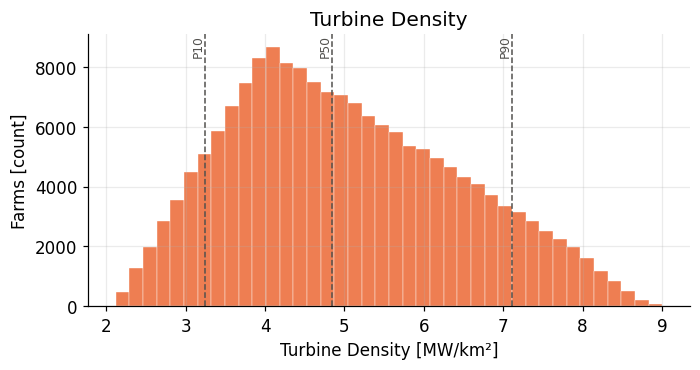

In [47]:
density = arrivals_s1_bk["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_BK, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

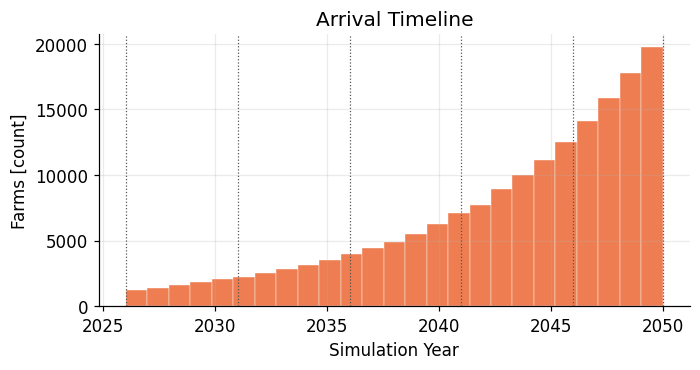

In [48]:
# only "speculative" farms draw a random arrival year -- self/real_layout/cluster_fixed are all fixed at YEAR_START
checkpoints = sorted(set(segments_s1_bk.start_year) | set(segments_s1_bk.end_year))
new_farm_years = arrivals_s1_bk.loc[arrivals_s1_bk.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_BK, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

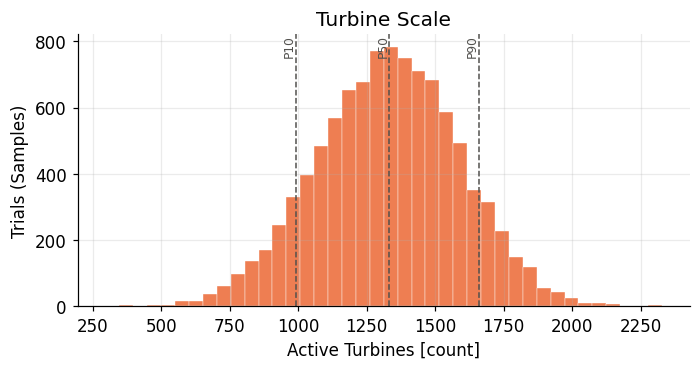

In [49]:
hist_with_percentiles(final_s1_bk["n_active_turbines"], COLOR_BK, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

With Bastankhah, the active AEP of the self is at a different level, with a P10 of approximately 3,237.7 GWh, a median of 3,296.2 GWh, and a P90 of 3,338.0 GWh. These values are higher than those obtained with Super Gaussian for the same scenario, which already indicates that Bastankhah is calculating lower losses for these worlds.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

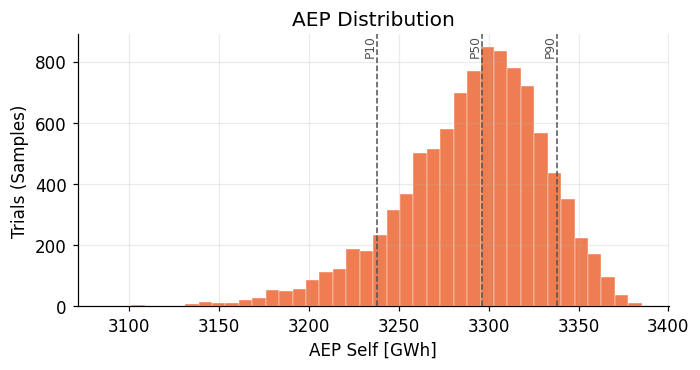

In [50]:
hist_with_percentiles(final_s1_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

Combined AEP is also higher with Bastankhah, with a median of approximately 79.5 TWh, compared with 74.6 TWh for Super Gaussian. Since capacity, farms, and climate are the same, this difference comes from how each model represents wake interactions across the whole scenario.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

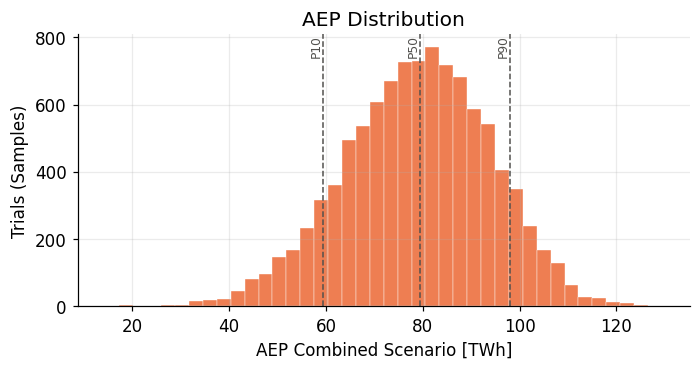

In [51]:
hist_with_percentiles(final_s1_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

Wake loss of the self with Bastankhah has a P10 of 1.18%, a median of 1.99%, and a P90 of 3.57%. Compared with Super Gaussian, the distribution shifts toward lower losses. This difference will be shown directly in the final model comparison, but it already appears here in both the median and the P90 tail.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

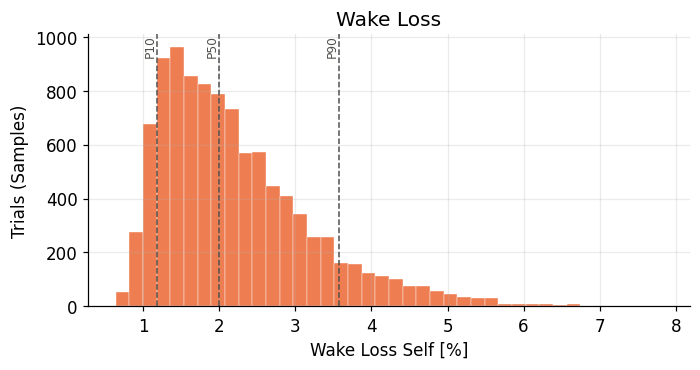

In [52]:
hist_with_percentiles(final_s1_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

Convergence is checked again to make sure that the Bastankhah percentiles are not also a result of trial order. The behavior is the same as in the previous block: after many trials, the bands stabilize and the final percentiles can be compared with Super Gaussian with more confidence.

In [53]:
np.percentile(final_s1_bk['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([3237.72655153, 3296.18755944, 3337.99303314])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

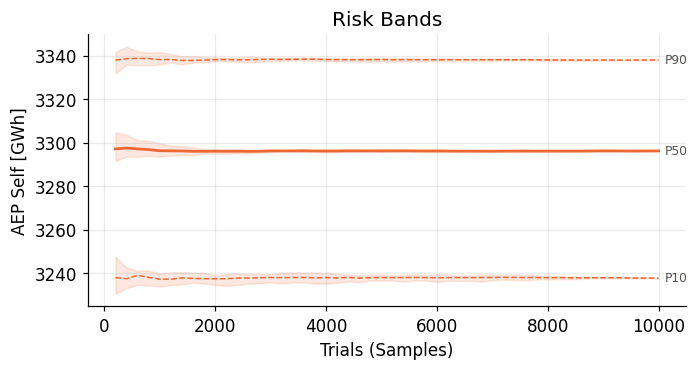

In [54]:
convergence_bands(final_s1_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Risk Bands")

In [55]:
np.percentile(final_s1_bk['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([59.28191457, 79.46088275, 97.95694788])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

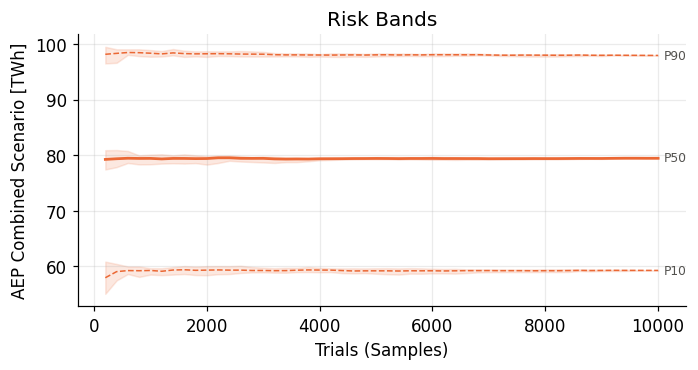

In [56]:
convergence_bands(final_s1_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Risk Bands")

In [57]:
np.percentile(final_s1_bk['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([1.17567002, 1.99098375, 3.56853757])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

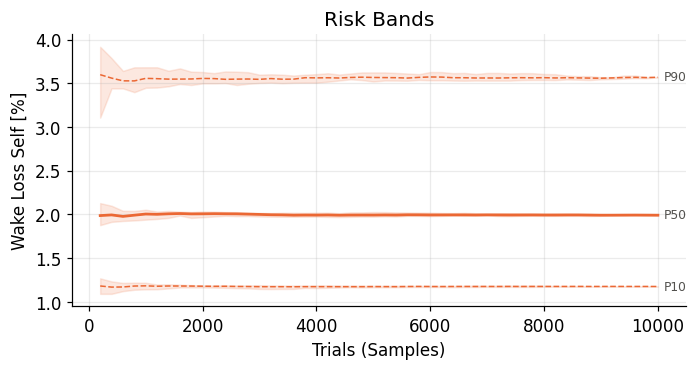

In [58]:
convergence_bands(final_s1_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Risk Bands")

The time trajectory repeats the regional growth seen before: combined AEP increases as new farms enter, and wake loss also increases, but at a lower level than with Super Gaussian. So the time pattern does not disappear when the model changes; what changes is the magnitude of the calculated loss.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

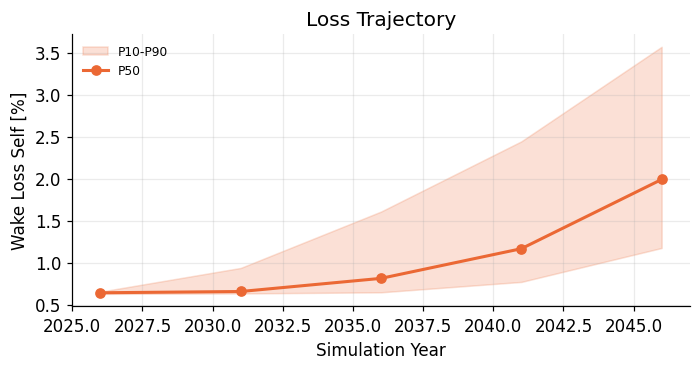

In [59]:
segment_trajectory(segments_s1_bk, COLOR_BK, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

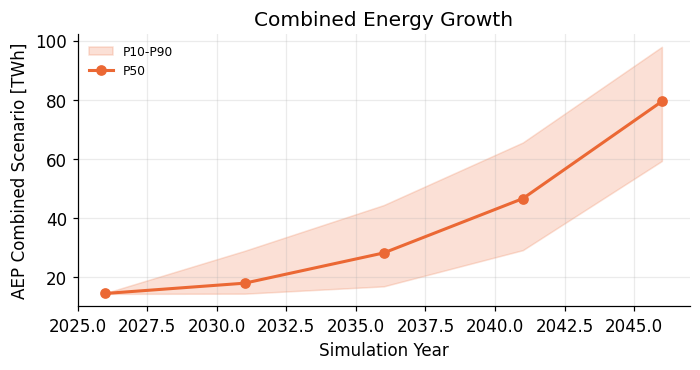

In [60]:
segments_s1_bk["world_aep_twh"] = segments_s1_bk["world_aep_gwh"] / 1000
segment_trajectory(segments_s1_bk, COLOR_BK, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

The association between combined AEP and wake loss remains positive, with a correlation of 0.355, very close to the value seen with Super Gaussian. This suggests that both models agree on the general direction of the effect: larger scenarios tend to increase loss at the self, even if they disagree on the magnitude of that loss.

In [61]:
final_s1_bk[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.3554151999081491)

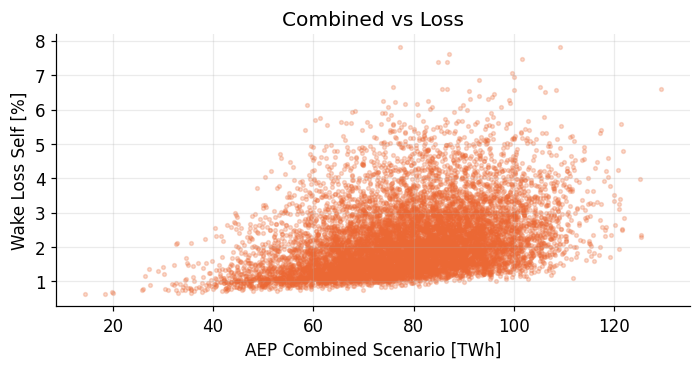

In [62]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s1_bk["world_aep_gwh"] / 1000, final_s1_bk["loss_pct"], s=6, alpha=0.25, color=COLOR_BK)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

In [63]:
capacity_bins_s1_bk = segments_s1_bk.copy()
capacity_bins_s1_bk["capacity_bin"] = pd.qcut(capacity_bins_s1_bk["active_mw"], 20, duplicates="drop")
sat_table_s1_bk = capacity_bins_s1_bk.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s1_bk

,active_mw,world_aep_twh,active_aep_gwh
0,3612.766276,14.866841,3343.302966
1,5014.106856,20.529312,3339.448617
2,5770.765118,23.518696,3336.933575
3,6603.671068,26.748254,3333.347249
4,7560.538200,30.507782,3330.746124
5,8663.116200,34.807763,3328.219334
6,9888.961615,39.561869,3323.731630
7,11266.670868,44.979885,3319.898261
8,12888.420200,51.277372,3315.317954
9,14792.860600,58.725474,3307.337741


In [64]:
np.diff(sat_table_s1_bk['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 5.66247016,  2.98938423,  3.22955799,  3.75952848,  4.29998114,
        4.75410603,  5.41801525,  6.29748756,  7.44810203,  8.26841852,
        8.67227289,  8.88604746, 12.9368694 ])

The same trade-off seen with Super Gaussian appears again here: combined energy grows with active capacity and self AEP decreases as the scenario becomes larger. The difference is that the decrease in self AEP is smaller with Bastankhah, going from approximately 3,343 GWh to 3,277 GWh between the extreme capacity bins, while combined energy grows from approximately 14.9 to 97.5 TWh.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

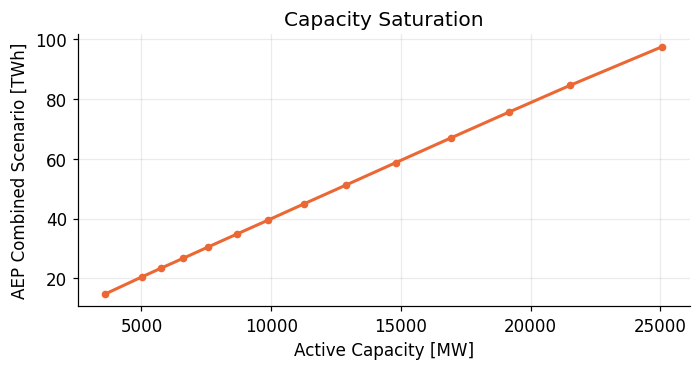

In [65]:
binned_line_plot(sat_table_s1_bk["active_mw"], sat_table_s1_bk["world_aep_twh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

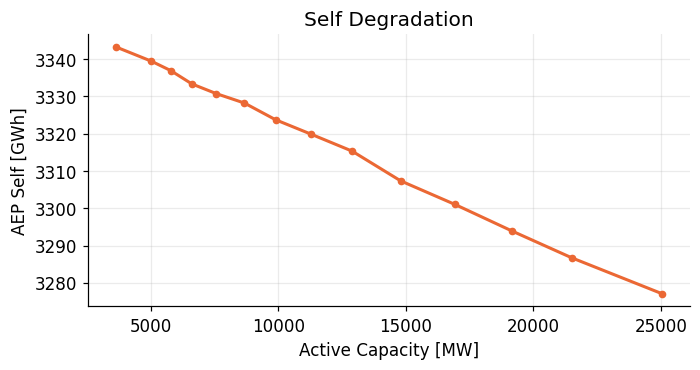

In [66]:
binned_line_plot(sat_table_s1_bk["active_mw"], sat_table_s1_bk["active_aep_gwh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

## Scenario 2, Super Gaussian model

In Scenario 2, the self already starts inside a more heavily loaded fixed cluster, and speculative expansion occurs as infill. So, unlike Scenario 1, wake loss is already at a high level from the first checkpoint. This section shows how the new combined-energy variable behaves in this scenario and how increasing capacity relates to an initial condition that is already more exposed.

## Scenario 2 -- Fixed cluster + speculative infill expansion -- Wake Model: SuperGaussian

### Phase 1 -> Ingestion, Audit & Correlation Screening

The audit again confirms 10,000 complete trials and five segments per trial. Climate inputs follow the same distribution used before, so the difference in Scenario 2 does not come from sampled climate. Mean density was 4.88 MW/km² and the mean number of speculative farms was 10.71, lower than in Scenario 1, which is consistent with infill expansion inside a region that already has more occupied areas.

In [67]:
trials_s2_sg.shape, arrivals_s2_sg.shape, segments_s2_sg.shape

((10000, 13), (237139, 9), (50000, 16))

In [68]:
trials_s2_sg.isna().sum().sum(), arrivals_s2_sg.isna().sum().sum(), segments_s2_sg.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [69]:
trials_s2_sg.trial_id.nunique(), segments_s2_sg.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

### Input Uncertainty

In [70]:
trials_s2_sg[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,-0.007173,0.999985,0.999829
std,1.458700,0.004755,0.025766
min,-3.935272,0.990664,0.941646
25%,-0.989038,0.996604,0.982145
50%,-0.020011,0.999940,0.999569
75%,0.990218,1.003288,1.017452
max,3.935272,1.010155,1.070733


In [71]:
final_s2_sg['mean_density_mw_km2'].describe()

count    10000.000000
mean         4.875858
std          0.241939
min          4.129346
25%          4.709026
50%          4.867692
75%          5.038731
max          5.794355
Name: mean_density_mw_km2, dtype: float64

In [72]:
final_s2_sg['n_speculative'].describe()

count    10000.000000
mean        10.713900
std          2.384788
min          3.000000
25%          9.000000
50%         11.000000
75%         12.000000
max         19.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

In Scenario 2 with Super Gaussian, self AEP is even more associated with the speed multiplier, with a correlation of 0.786. Combined AEP remains almost entirely associated with active capacity, with 0.990, and turbine count, with 0.946. So the main separation between the two metrics appears again: the energy of the whole world is mainly driven by scenario scale, while self production is more sensitive to climate and the wakes already around it.

In [73]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s2_sg = final_s2_sg[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s2_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.045938,0.019618
climate_speed_multiplier,0.785611,0.073681
climate_spread_multiplier,0.126502,0.014341
n_speculative,-0.065925,0.058427
mean_density_mw_km2,0.023284,-0.035160
active_mw,-0.286209,0.990124
n_active_turbines,-0.279076,0.945752


In [74]:
spearman_s2_sg = final_s2_sg[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s2_sg

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.048307,0.017930
climate_speed_multiplier,0.801244,0.070458
climate_spread_multiplier,0.118321,0.013683
n_speculative,-0.063146,0.044394
mean_density_mw_km2,0.026321,-0.029838
active_mw,-0.272232,0.989898
n_active_turbines,-0.263985,0.945829


In [75]:
pearson_s2_sg['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.785611
active_mw                   -0.286209
n_active_turbines           -0.279076
climate_spread_multiplier    0.126502
n_speculative               -0.065925
climate_rotation_deg         0.045938
mean_density_mw_km2          0.023284
Name: active_aep_gwh, dtype: float64

In [76]:
pearson_s2_sg['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.990124
n_active_turbines            0.945752
climate_speed_multiplier     0.073681
n_speculative                0.058427
mean_density_mw_km2         -0.035160
climate_rotation_deg         0.019618
climate_spread_multiplier    0.014341
Name: world_aep_gwh, dtype: float64

### Phase 2 --> Dual Energy & Risk Breakdown

The density and arrival distributions keep the same general rules used before, but they are now applied to the remaining space in Scenario 2. Even with fewer speculative farms on average, the final turbine count is still high because the scenario already starts with a fixed cluster and additional expansion is added on top of that base.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

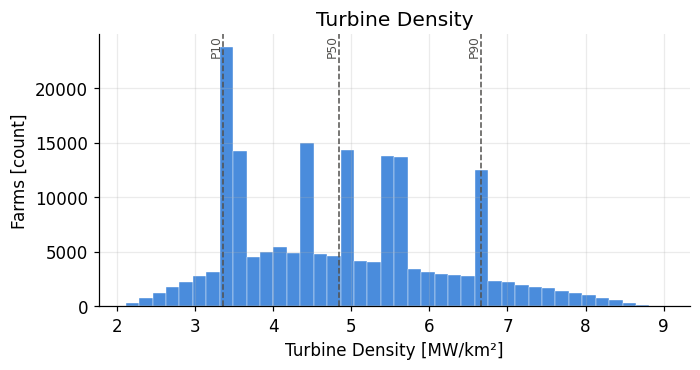

In [77]:
density = arrivals_s2_sg["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_SG, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

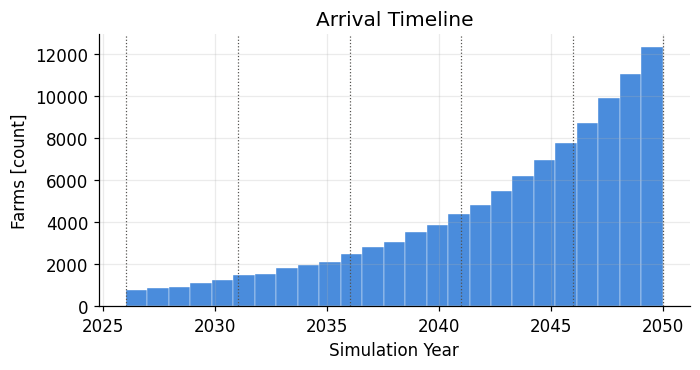

In [78]:
# only "speculative" farms draw a random arrival year -- self/real_layout/cluster_fixed are all fixed at YEAR_START
checkpoints = sorted(set(segments_s2_sg.start_year) | set(segments_s2_sg.end_year))
new_farm_years = arrivals_s2_sg.loc[arrivals_s2_sg.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_SG, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

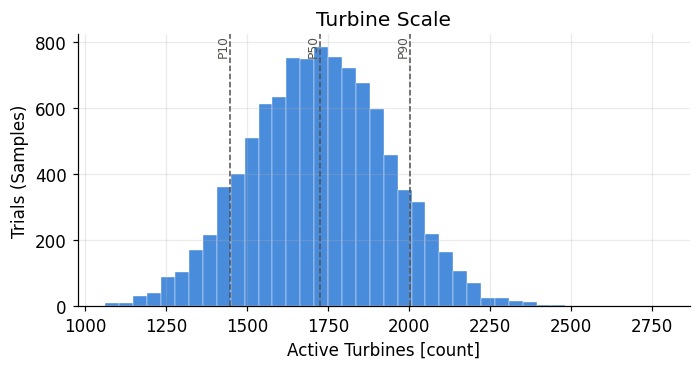

In [79]:
hist_with_percentiles(final_s2_sg["n_active_turbines"], COLOR_SG, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

At the last checkpoint, self AEP has a P10 of approximately 2,857.2 GWh, a median of 2,893.6 GWh, and a P90 of 2,927.4 GWh. The combined AEP of the scenario goes from 71.2 TWh at P10 to 100.4 TWh at P90, with a median of 86.5 TWh. At the same time, wake loss is at another level: P10 is 10.50%, the median is 10.99%, and P90 is 11.75%. So Scenario 2 produces more total energy than Scenario 1 in most trials, but the self receives a much larger loss because it is already inside a more loaded region.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

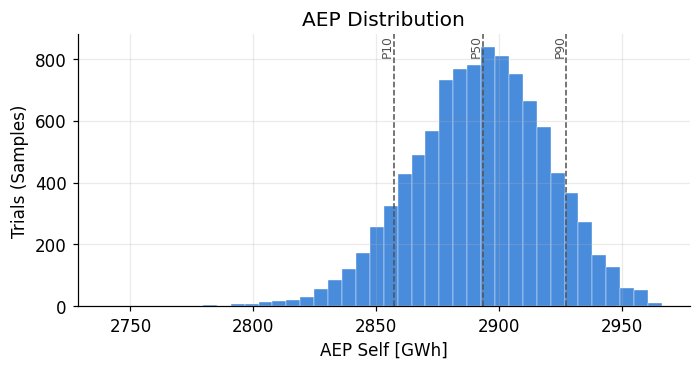

In [80]:
hist_with_percentiles(final_s2_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

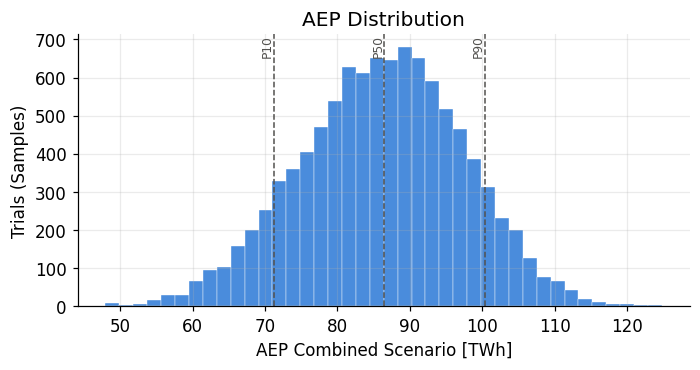

In [81]:
hist_with_percentiles(final_s2_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

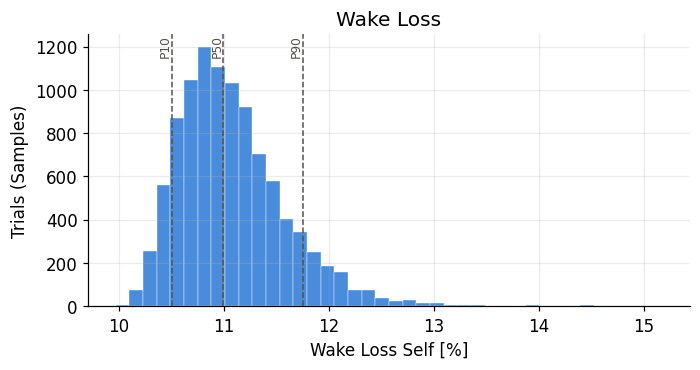

In [82]:
hist_with_percentiles(final_s2_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

The percentiles of self AEP, combined AEP, and wake loss are also tracked as the sample grows. The reading is the same as in the previous plots: checking whether the values used to compare scenarios have already stabilized near 10,000 trials without depending on a specific order of draws.

In [83]:
np.percentile(final_s2_sg['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([2857.21567758, 2893.57511345, 2927.43426769])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

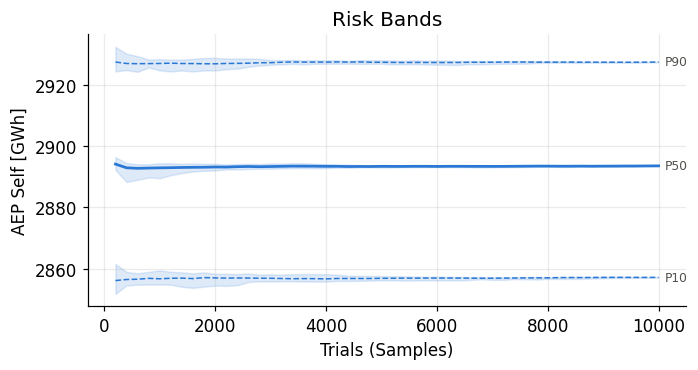

In [84]:
convergence_bands(final_s2_sg["active_aep_gwh"], COLOR_SG, "AEP Self [GWh]", "Risk Bands")

In [85]:
np.percentile(final_s2_sg['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([ 71.22092487,  86.49267728, 100.3918548 ])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

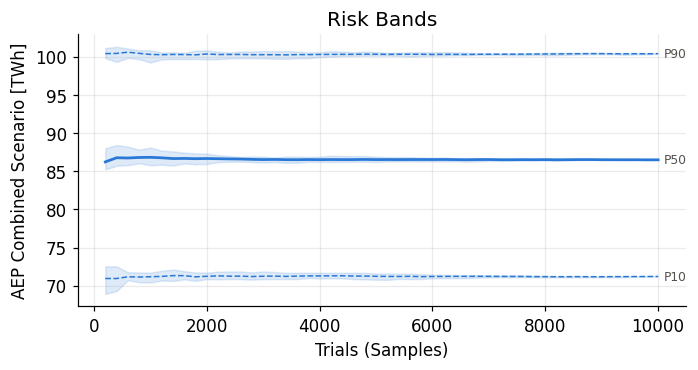

In [86]:
convergence_bands(final_s2_sg["world_aep_gwh"] / 1000, COLOR_SG, "AEP Combined Scenario [TWh]", "Risk Bands")

In [87]:
np.percentile(final_s2_sg['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([10.50446012, 10.99286281, 11.74848312])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

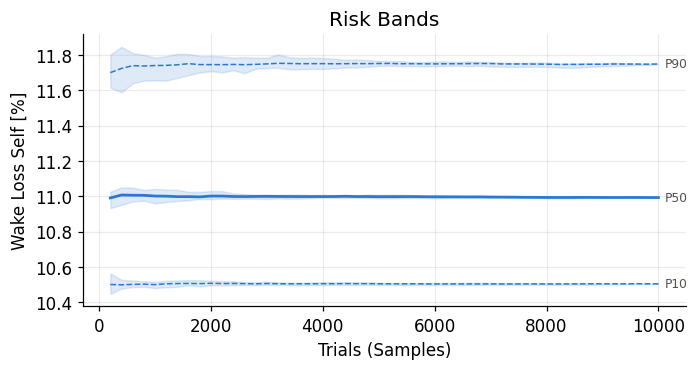

In [88]:
convergence_bands(final_s2_sg["loss_pct"], COLOR_SG, "Wake Loss Self [%]", "Risk Bands")

Wake loss starts near 10.2% and grows to approximately 11.0% at the end of the horizon, while combined AEP grows as infill enters operation. Here it becomes clearer that expansion does not create risk from zero; it adds more uncertainty and more loss on top of an environment that already starts with relevant wakes.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

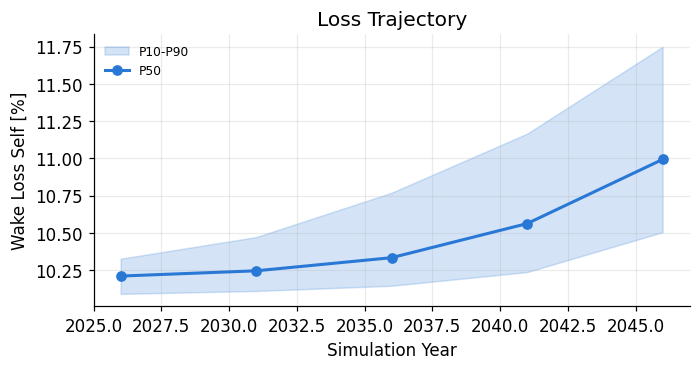

In [89]:
segment_trajectory(segments_s2_sg, COLOR_SG, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

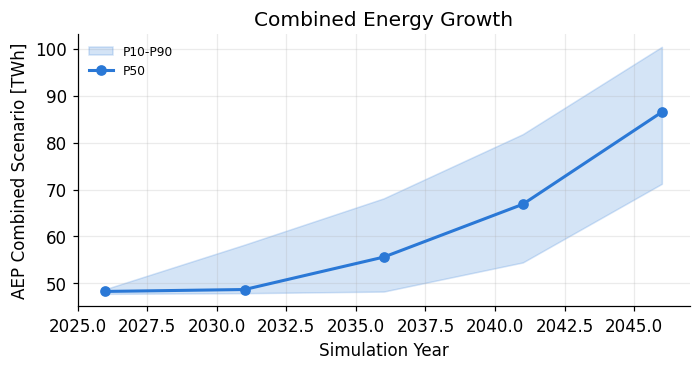

In [90]:
segments_s2_sg["world_aep_twh"] = segments_s2_sg["world_aep_gwh"] / 1000
segment_trajectory(segments_s2_sg, COLOR_SG, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

The correlation between combined AEP and wake loss rises to 0.469 in Scenario 2, higher than in Scenario 1. This shows that, in this more heavily loaded environment, worlds that reach higher total production also tend to have a clearer link with larger losses at the self. Still, the points do not form a perfect line, so geometry and the relative positions of farms remain important.

In [91]:
final_s2_sg[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.4686596904102899)

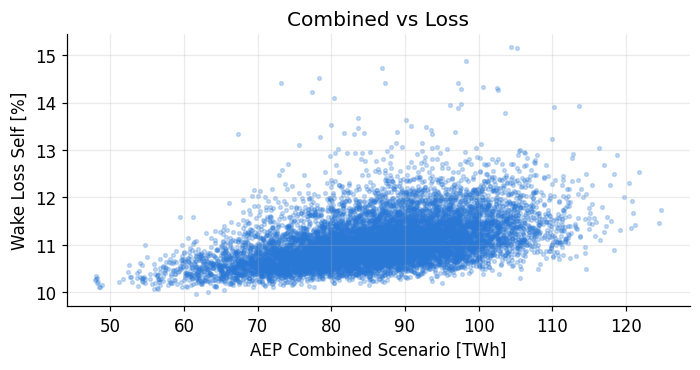

In [92]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s2_sg["world_aep_gwh"] / 1000, final_s2_sg["loss_pct"], s=6, alpha=0.25, color=COLOR_SG)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

In [93]:
capacity_bins_s2_sg = segments_s2_sg.copy()
capacity_bins_s2_sg["capacity_bin"] = pd.qcut(capacity_bins_s2_sg["active_mw"], 20, duplicates="drop")
sat_table_s2_sg = capacity_bins_s2_sg.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s2_sg

,active_mw,world_aep_twh,active_aep_gwh
0,13504.897713,48.519623,2920.468050
1,14617.820016,52.729885,2916.794107
2,15203.486034,54.857628,2916.097070
3,15857.720972,57.199023,2913.420470
4,16607.361600,59.876873,2911.889200
5,17464.091600,62.916959,2909.702502
6,18430.686800,66.293601,2906.729266
7,19540.044582,70.299337,2904.724087
8,20775.936575,74.628664,2901.081525
9,22155.730200,79.534501,2896.358444


In [94]:
np.diff(sat_table_s2_sg['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([4.21026134, 2.1277436 , 2.34139509, 2.67784933, 3.04008674,
       3.37664153, 4.00573643, 4.32932717, 4.90583697, 5.32885011,
       5.9698353 , 9.40834124])

Combined energy grows from approximately 48.5 TWh to 100.2 TWh between the extreme capacity bins, while mean self AEP decreases from approximately 2,920 GWh to 2,883 GWh. The decrease is smaller in GWh than in Scenario 1, but it happens on top of an already high wake-loss level, so it does not mean that the scenario is less critical for the self.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

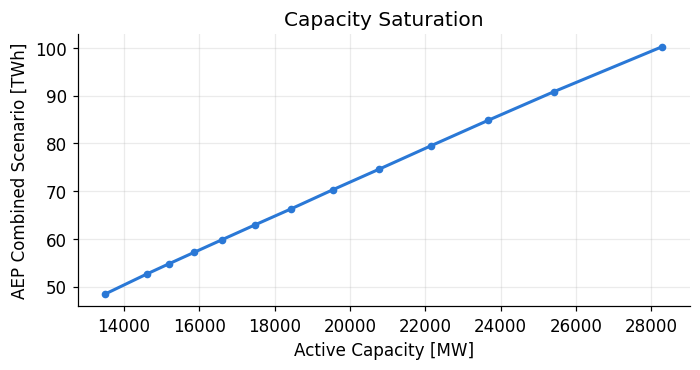

In [95]:
binned_line_plot(sat_table_s2_sg["active_mw"], sat_table_s2_sg["world_aep_twh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

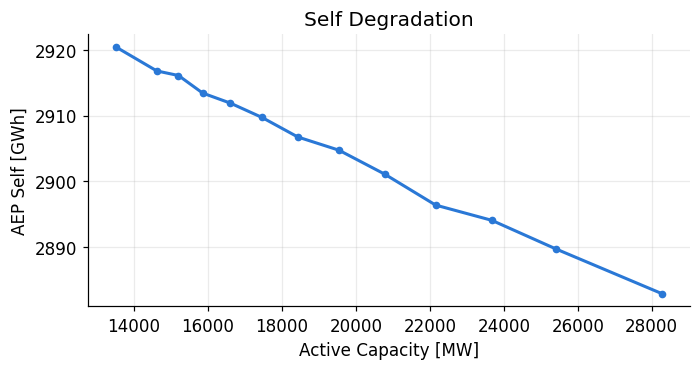

In [96]:
binned_line_plot(sat_table_s2_sg["active_mw"], sat_table_s2_sg["active_aep_gwh"], COLOR_SG,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

## Scenario 2, Bastankhah model

This section runs Bastankhah on the same Scenario 2 worlds that were just used with Super Gaussian. The equality check between `trials` and `arrivals` again confirms that the only change between the branches is the wake model.

## Scenario 2 -- Fixed cluster + speculative infill expansion -- Wake Model: Bastankhah

### Phase 1 -- Ingestion, Audit & Correlation Screening

The input data again appear equal to those of Scenario 2 with Super Gaussian, including climate, mean density, and the number of speculative farms. Since this was already explained before, the focus here is on the new results that Bastankhah produces for the same set of scenarios.

In [97]:
trials_s2_bk.shape, arrivals_s2_bk.shape, segments_s2_bk.shape

((10000, 13), (237139, 9), (50000, 16))

In [98]:
trials_s2_bk.isna().sum().sum(), arrivals_s2_bk.isna().sum().sum(), segments_s2_bk.isna().sum().sum()

(np.int64(0), np.int64(140000), np.int64(0))

In [99]:
trials_s2_bk.trial_id.nunique(), segments_s2_bk.trial_id.nunique()  # integrity: every trial reached the final segment

(10000, 10000)

In [100]:
# scenario generation never touches model_name (PIPELINE.md) -- trials/arrivals should be byte-identical to the SuperGaussian branch
cols = ["seed", "n_speculative", "fixed_capacity_mw", "climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier"]
trials_s2_bk[cols].equals(trials_s2_sg[cols]), arrivals_s2_bk.equals(arrivals_s2_sg)

(True, True)

### Input Uncertainty

In [101]:
trials_s2_bk[['climate_rotation_deg', 'climate_speed_multiplier', 'climate_spread_multiplier']].describe()

,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
count,10000.000000,10000.000000,10000.000000
mean,-0.007173,0.999985,0.999829
std,1.458700,0.004755,0.025766
min,-3.935272,0.990664,0.941646
25%,-0.989038,0.996604,0.982145
50%,-0.020011,0.999940,0.999569
75%,0.990218,1.003288,1.017452
max,3.935272,1.010155,1.070733


In [102]:
final_s2_bk['mean_density_mw_km2'].describe()

count    10000.000000
mean         4.875858
std          0.241939
min          4.129346
25%          4.709026
50%          4.867692
75%          5.038731
max          5.794355
Name: mean_density_mw_km2, dtype: float64

In [103]:
final_s2_bk['n_speculative'].describe()

count    10000.000000
mean        10.713900
std          2.384788
min          3.000000
25%          9.000000
50%         11.000000
75%         12.000000
max         19.000000
Name: n_speculative, dtype: float64

### Correlation vs Outputs

The general pattern remains: combined AEP almost follows active capacity directly, with a correlation of 0.994, and turbine count, with 0.951. For self AEP, the speed multiplier becomes even more dominant, with a correlation of 0.901. Compared with Super Gaussian, Bastankhah keeps the same direction in the main relationships but changes how much self AEP responds to climate and how much it loses to wakes.

In [104]:
predictors = ["climate_rotation_deg", "climate_speed_multiplier", "climate_spread_multiplier",
              "n_speculative", "mean_density_mw_km2", "active_mw", "n_active_turbines"]
targets = ["active_aep_gwh", "world_aep_gwh"]

pearson_s2_bk = final_s2_bk[predictors + targets].corr(method="pearson").loc[predictors, targets]
pearson_s2_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.060337,0.018266
climate_speed_multiplier,0.901163,0.069123
climate_spread_multiplier,0.120083,0.012684
n_speculative,-0.041472,0.046522
mean_density_mw_km2,0.016981,-0.027986
active_mw,-0.187144,0.993566
n_active_turbines,-0.181679,0.951052


In [105]:
spearman_s2_bk = final_s2_bk[predictors + targets].corr(method="spearman").loc[predictors, targets]
spearman_s2_bk

,active_aep_gwh,world_aep_gwh
climate_rotation_deg,0.060345,0.016723
climate_speed_multiplier,0.905857,0.065873
climate_spread_multiplier,0.111066,0.012044
n_speculative,-0.041261,0.033782
mean_density_mw_km2,0.018679,-0.023356
active_mw,-0.174122,0.993437
n_active_turbines,-0.167639,0.951028


In [106]:
pearson_s2_bk['active_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Self

climate_speed_multiplier     0.901163
active_mw                   -0.187144
n_active_turbines           -0.181679
climate_spread_multiplier    0.120083
climate_rotation_deg         0.060337
n_speculative               -0.041472
mean_density_mw_km2          0.016981
Name: active_aep_gwh, dtype: float64

In [107]:
pearson_s2_bk['world_aep_gwh'].sort_values(key=abs, ascending=False)  # ranked drivers of AEP Combined Scenario

active_mw                    0.993566
n_active_turbines            0.951052
climate_speed_multiplier     0.069123
n_speculative                0.046522
mean_density_mw_km2         -0.027986
climate_rotation_deg         0.018266
climate_spread_multiplier    0.012684
Name: world_aep_gwh, dtype: float64

### Phase 2 -- Dual Energy & Risk Breakdown

The density, arrival, and physical-scale distributions are the same as in the Super Gaussian block for Scenario 2, so these plots work here only as a visual confirmation that the same worlds were used in both models.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Density'}, xlabel='Turbine Density [MW/km²]', ylabel='Farms [count]'>)

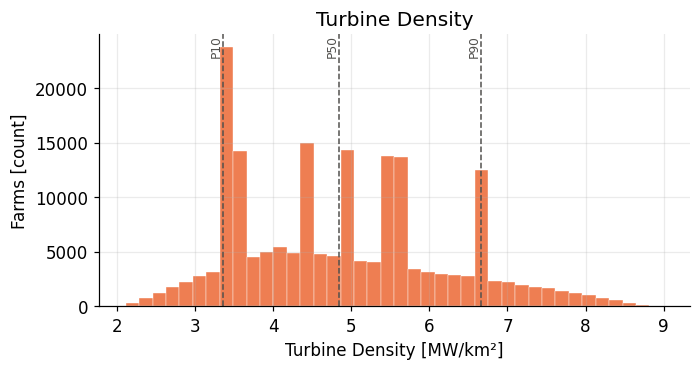

In [108]:
density = arrivals_s2_bk["rho_target_mw_km2"].dropna()
hist_with_percentiles(density, COLOR_BK, "Turbine Density [MW/km\u00b2]", "Farms [count]", "Turbine Density")

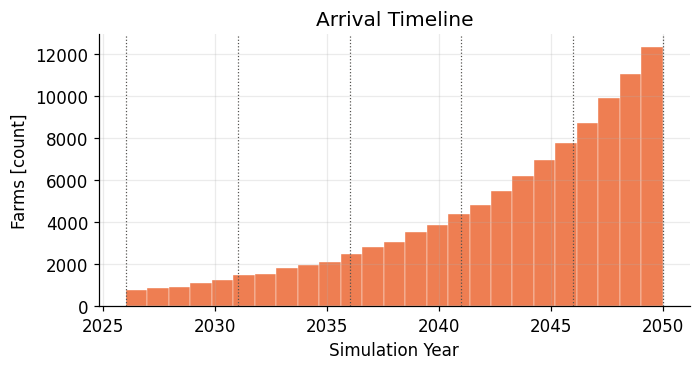

In [109]:
# only "speculative" farms draw a random arrival year -- self/real_layout/cluster_fixed are all fixed at YEAR_START
checkpoints = sorted(set(segments_s2_bk.start_year) | set(segments_s2_bk.end_year))
new_farm_years = arrivals_s2_bk.loc[arrivals_s2_bk.source == "speculative", "arrival_year"]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(new_farm_years, bins=25, color=COLOR_BK, alpha=0.85, edgecolor="white", linewidth=0.3)
for yr in checkpoints:
    ax.axvline(yr, color=COLOR_NEUTRAL, linestyle=":", linewidth=0.8)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Farms [count]"); ax.set_title("Arrival Timeline")
fig.tight_layout()

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Turbine Scale'}, xlabel='Active Turbines [count]', ylabel='Trials (Samples)'>)

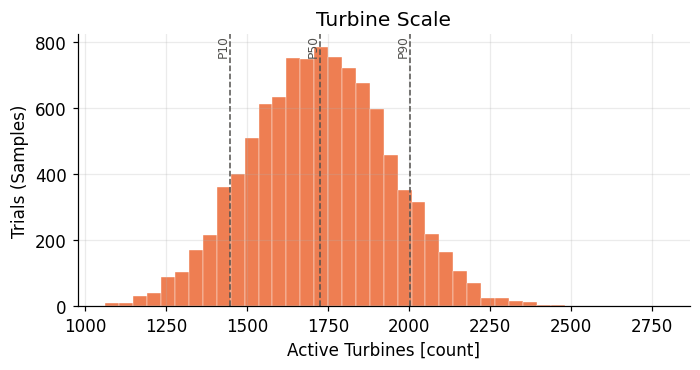

In [110]:
hist_with_percentiles(final_s2_bk["n_active_turbines"], COLOR_BK, "Active Turbines [count]", "Trials (Samples)", "Turbine Scale")

With Bastankhah, self AEP at the last checkpoint changes to a P10 of approximately 3,094.0 GWh, a median of 3,126.8 GWh, and a P90 of 3,158.2 GWh. Combined AEP has a median of 93.5 TWh, above the 86.5 TWh from Super Gaussian. Wake loss decreases to a P10 of 6.77%, a median of 7.05%, and a P90 of 7.50%. As in Scenario 1, Bastankhah calculates lower loss for the self and more energy for the whole scenario while using exactly the same farm construction.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Self [GWh]', ylabel='Trials (Samples)'>)

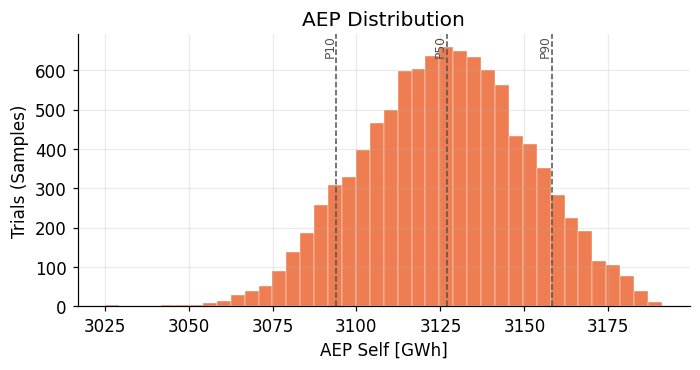

In [111]:
hist_with_percentiles(final_s2_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'AEP Distribution'}, xlabel='AEP Combined Scenario [TWh]', ylabel='Trials (Samples)'>)

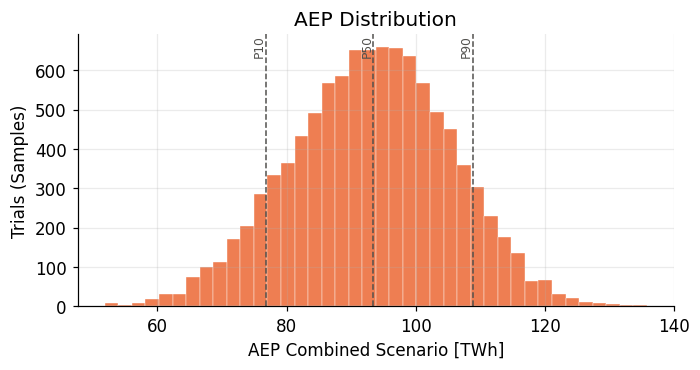

In [112]:
hist_with_percentiles(final_s2_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Trials (Samples)", "AEP Distribution")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

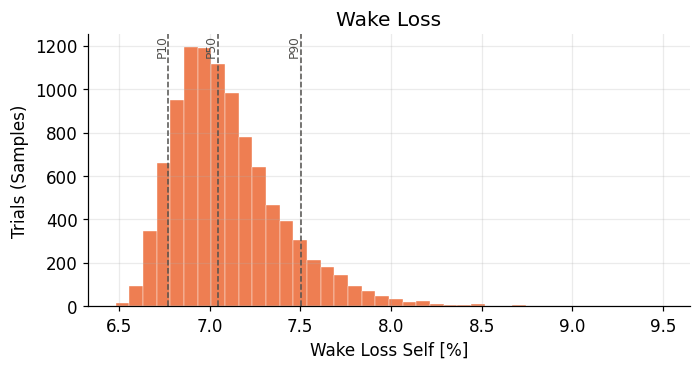

In [113]:
hist_with_percentiles(final_s2_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss")

Convergence and the trajectories confirm the same behavior seen before: the percentiles stabilize as the number of trials increases, combined energy grows over time, and wake loss stays high while increasing slightly through the horizon. The difference is that Bastankhah places this trajectory at a lower loss level than Super Gaussian.

In [114]:
np.percentile(final_s2_bk['active_aep_gwh'], [10, 50, 90])  # converged P10/P50/P90, AEP Self

array([3094.01696063, 3126.80439037, 3158.21655606])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Self [GWh]'>)

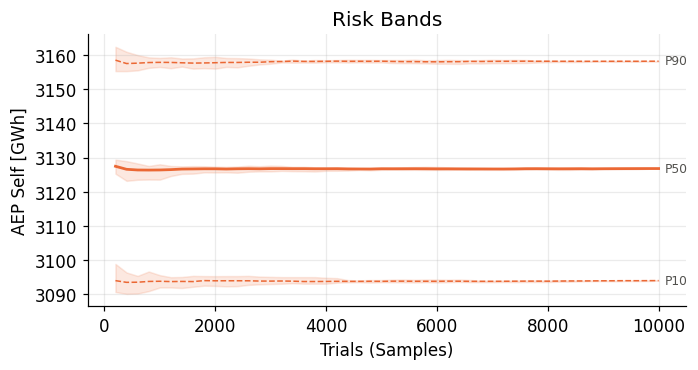

In [115]:
convergence_bands(final_s2_bk["active_aep_gwh"], COLOR_BK, "AEP Self [GWh]", "Risk Bands")

In [116]:
np.percentile(final_s2_bk['world_aep_gwh'] / 1000, [10, 50, 90])  # converged P10/P50/P90, AEP Combined

array([ 76.79426922,  93.45791384, 108.8385452 ])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='AEP Combined Scenario [TWh]'>)

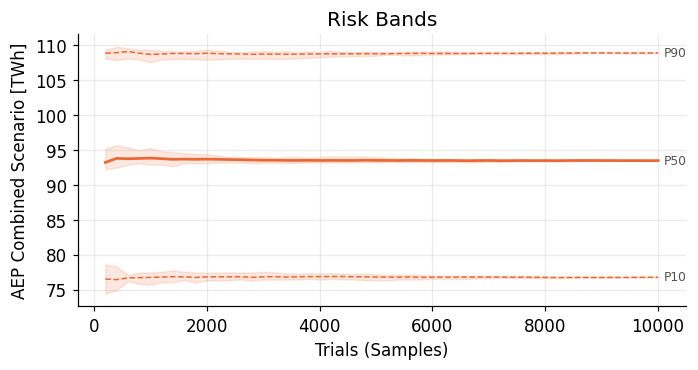

In [117]:
convergence_bands(final_s2_bk["world_aep_gwh"] / 1000, COLOR_BK, "AEP Combined Scenario [TWh]", "Risk Bands")

In [118]:
np.percentile(final_s2_bk['loss_pct'], [10, 50, 90])  # converged P10/P50/P90, Wake Loss Self

array([6.77343315, 7.04553792, 7.50425617])

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Risk Bands'}, xlabel='Trials (Samples)', ylabel='Wake Loss Self [%]'>)

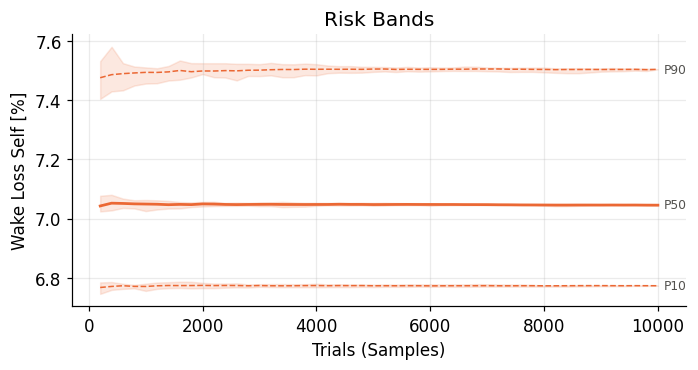

In [119]:
convergence_bands(final_s2_bk["loss_pct"], COLOR_BK, "Wake Loss Self [%]", "Risk Bands")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Loss Trajectory'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

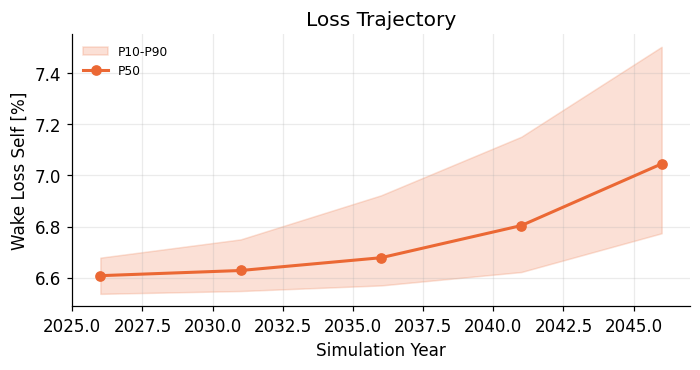

In [120]:
segment_trajectory(segments_s2_bk, COLOR_BK, "Wake Loss Self [%]", "Loss Trajectory", value_col="loss_pct")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Combined Energy Growth'}, xlabel='Simulation Year', ylabel='AEP Combined Scenario [TWh]'>)

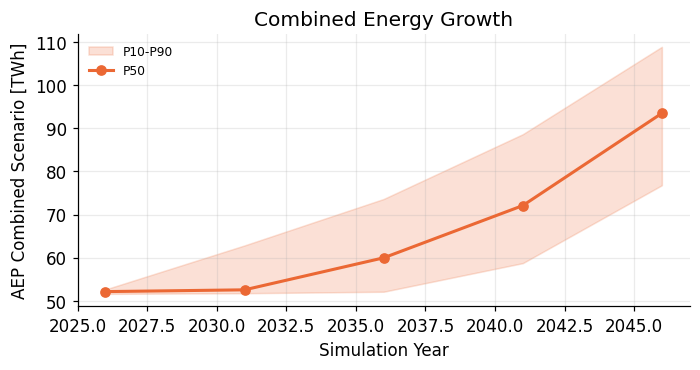

In [121]:
segments_s2_bk["world_aep_twh"] = segments_s2_bk["world_aep_gwh"] / 1000
segment_trajectory(segments_s2_bk, COLOR_BK, "AEP Combined Scenario [TWh]", "Combined Energy Growth", value_col="world_aep_twh")

### Phase 3 -- Regional Saturation & Cross-Variable Interaction

The correlation between combined energy and wake loss is 0.461, very close to the 0.469 found with Super Gaussian. So the two models again agree that greater regional development tends to come with greater loss at the self, even if the size of that loss is different.

In [122]:
final_s2_bk[['world_aep_gwh', 'loss_pct']].corr().iloc[0, 1]  # Combined AEP growth vs Self wake loss, final segment

np.float64(0.46133015028480123)

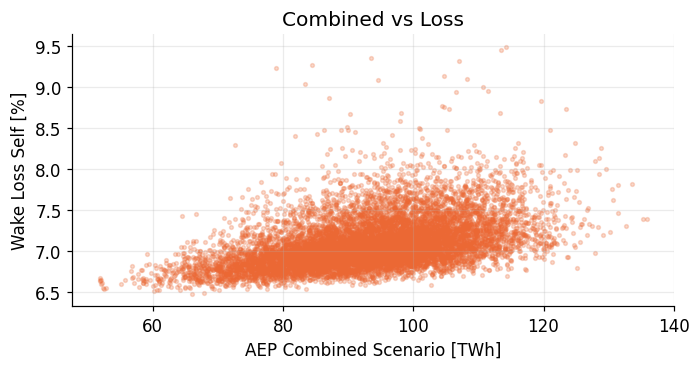

In [123]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s2_bk["world_aep_gwh"] / 1000, final_s2_bk["loss_pct"], s=6, alpha=0.25, color=COLOR_BK)
ax.set_xlabel("AEP Combined Scenario [TWh]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Combined vs Loss")
fig.tight_layout()

In [124]:
capacity_bins_s2_bk = segments_s2_bk.copy()
capacity_bins_s2_bk["capacity_bin"] = pd.qcut(capacity_bins_s2_bk["active_mw"], 20, duplicates="drop")
sat_table_s2_bk = capacity_bins_s2_bk.groupby("capacity_bin", observed=True).agg(
    active_mw=("active_mw", "mean"),
    world_aep_twh=("world_aep_gwh", lambda x: x.mean() / 1000),
    active_aep_gwh=("active_aep_gwh", "mean"),
).reset_index(drop=True)
sat_table_s2_bk

,active_mw,world_aep_twh,active_aep_gwh
0,13504.897713,52.406975,3143.020270
1,14617.820016,56.886610,3140.820839
2,15203.486034,59.174088,3140.731381
3,15857.720972,61.694570,3138.795897
4,16607.361600,64.588672,3138.031895
5,17464.091600,67.880969,3136.743287
6,18430.686800,71.552210,3134.844794
7,19540.044582,75.876284,3133.972495
8,20775.936575,80.590895,3131.511739
9,22155.730200,85.904024,3128.293697


In [125]:
np.diff(sat_table_s2_bk['world_aep_twh'])  # marginal TWh gained per capacity bin -- shrinking values = saturation

array([ 4.47963421,  2.28747862,  2.52048211,  2.89410185,  3.29229644,
        3.67124181,  4.32407341,  4.7146116 ,  5.31312894,  5.8189094 ,
        6.55234575, 10.44776129])

The capacity-bin reading repeats the trade-off seen in the other blocks. Combined energy increases from approximately 52.4 TWh to 108.7 TWh, while self AEP decreases from approximately 3,143 GWh to 3,121 GWh. The decrease appears smaller than with Super Gaussian, but it follows the same direction, showing that the model changes the magnitude rather than the general logic of the expansion effect.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Capacity Saturation'}, xlabel='Active Capacity [MW]', ylabel='AEP Combined Scenario [TWh]'>)

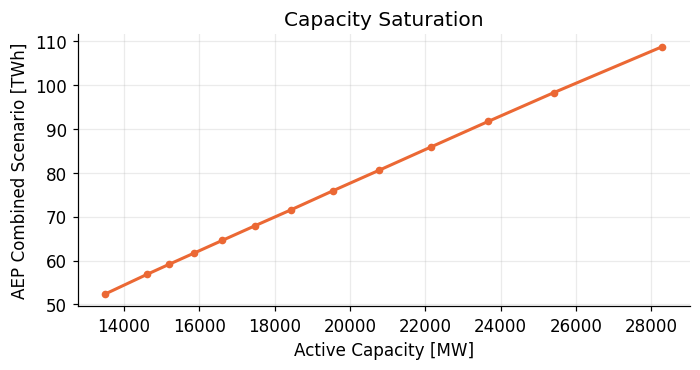

In [126]:
binned_line_plot(sat_table_s2_bk["active_mw"], sat_table_s2_bk["world_aep_twh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Combined Scenario [TWh]", "Capacity Saturation")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Self Degradation'}, xlabel='Active Capacity [MW]', ylabel='AEP Self [GWh]'>)

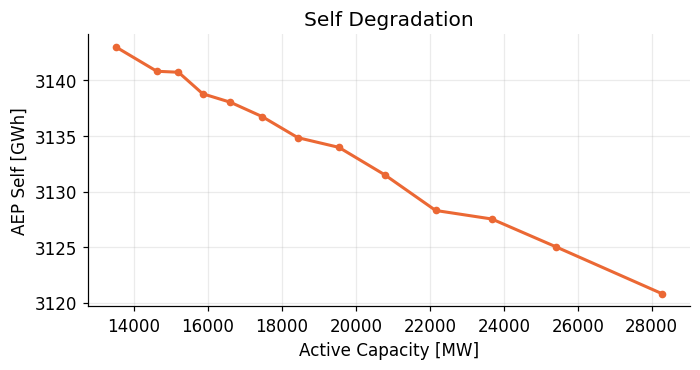

In [127]:
binned_line_plot(sat_table_s2_bk["active_mw"], sat_table_s2_bk["active_aep_gwh"], COLOR_BK,
                  "Active Capacity [MW]", "AEP Self [GWh]", "Self Degradation")

# Comparison between the wake models

after analyzing each branch separately, this section compares Super Gaussian and Bastankhah directly. Since the same scenarios were used in both models, the differences observed here are not caused by different density, arrival, capacity, or climate.   They show model uncertainty, meaning how much the wake-loss and AEP response changes whenn the same physical situation is calculated with two wake formulations.

### Direct Wake Model Comparison

## Scenario 1, difference between models

In Scenario 1, the two wake-loss distributions are clearly separated. Super Gaussian has a median of 3.59%, while Bastankhah has 1.99%, a difference of approximately 1.60 percentage points and at P90, Super Gaussian reaches 6.12% and Bastankhah 3.57%, a difference of approximately 2.55 percentage points... so the divergence increases in the worlds with higher loss.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss Comparison'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

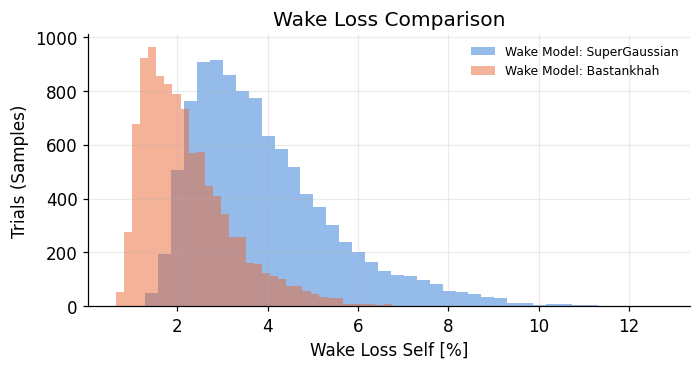

In [128]:
overlay_hist(final_s1_sg["loss_pct"], "Wake Model: SuperGaussian", COLOR_SG,
             final_s1_bk["loss_pct"], "Wake Model: Bastankhah", COLOR_BK,
             "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss Comparison")

The trajectories show that both models agree that wake loss grows with scenario development, but Bastankhah keeps lower losses throughout the whole horizon. The distance between the curves increases toward the end, when more capacity has already been built, so model choice becomes more important precisely in the worlds with greater regional development.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Model Divergence'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

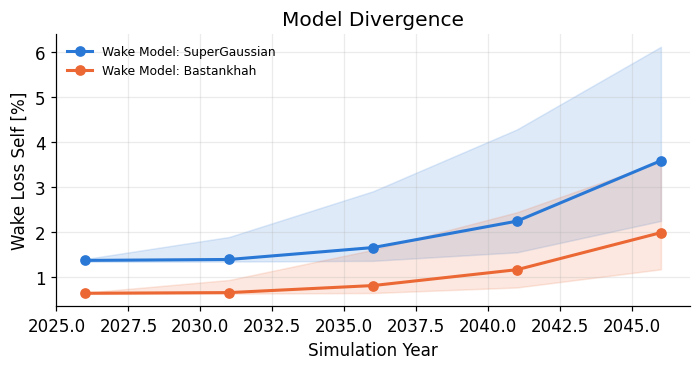

In [129]:
overlay_trajectory(segments_s1_sg, "Wake Model: SuperGaussian", COLOR_SG,
                    segments_s1_bk, "Wake Model: Bastankhah", COLOR_BK,
                    "Wake Loss Self [%]", "Model Divergence", value_col="loss_pct")

### Far-Wake Divergence Analysis

The difference between the models also appears when wake loss is related to active capacity. The estimated slope is approximately 0.000145 percentage points per MW for Super Gaussian and 0.000089 for Bastankhah. These values should not be read as a simple causal relationship per MW, but they help summarize that, within this set of trials, Super Gaussian responds more strongly to increasing regional capacity.

In [130]:
p50_sg, p90_sg = np.percentile(final_s1_sg["loss_pct"], [50, 90])
p50_bk, p90_bk = np.percentile(final_s1_bk["loss_pct"], [50, 90])
{"P50_SuperGaussian": p50_sg, "P50_Bastankhah": p50_bk, "P50_delta": p50_sg - p50_bk,
  "P90_SuperGaussian": p90_sg, "P90_Bastankhah": p90_bk, "P90_delta": p90_sg - p90_bk}

{'P50_SuperGaussian': np.float64(3.590541206920258),
 'P50_Bastankhah': np.float64(1.9909837482089796),
 'P50_delta': np.float64(1.5995574587112782),
 'P90_SuperGaussian': np.float64(6.1217605791465095),
 'P90_Bastankhah': np.float64(3.568537565755776),
 'P90_delta': np.float64(2.5532230133907334)}

In [131]:
# system sensitivity to distant/aggregate buildout: slope of Wake Loss Self against total active capacity, per model
slope_sg = np.polyfit(final_s1_sg["active_mw"], final_s1_sg["loss_pct"], 1)[0]
slope_bk = np.polyfit(final_s1_bk["active_mw"], final_s1_bk["loss_pct"], 1)[0]
{"slope_pct_per_MW_SuperGaussian": slope_sg, "slope_pct_per_MW_Bastankhah": slope_bk}

{'slope_pct_per_MW_SuperGaussian': np.float64(0.0001454176984167664),
 'slope_pct_per_MW_Bastankhah': np.float64(8.886588248524089e-05)}

The scatter plot shows the same idea visually. For the same active-capacity range, the Super Gaussian cloud sits above the Bastankhah cloud in most cases. There is still spread within each model because farm locations and climate change across trials, but the separation between the clouds shows that model difference is relevant for risk estimation.

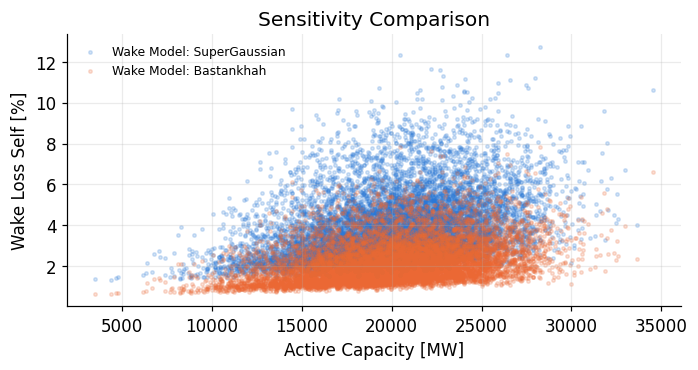

In [132]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s1_sg["active_mw"], final_s1_sg["loss_pct"], s=5, alpha=0.2, color=COLOR_SG, label="Wake Model: SuperGaussian")
ax.scatter(final_s1_bk["active_mw"], final_s1_bk["loss_pct"], s=5, alpha=0.2, color=COLOR_BK, label="Wake Model: Bastankhah")
ax.set_xlabel("Active Capacity [MW]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Sensitivity Comparison")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## Scenario 2, difference between models

In Scenario 2, both models continue to show a more heavily loaded region than in Scenario 1, but the difference between them becomes even larger in absolute terms. This matters because the scenario already starts with high wake loss, so model uncertainty is added to a regional condition that is already more critical for the self.

### Direct Wake Model Comparison

In Scenario 2, Super Gaussian has a median wake loss of 10.99%, while Bastankhah has 7.05%, a difference of approximately 3.95 percentage points. At P90, the difference rises to approximately 4.24 percentage points, with 11.75% for Super Gaussian and 7.50% for Bastankhah. Both models still agree that Scenario 2 has higher losses than Scenario 1, but they disagree in an important way on the level of that loss.

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Wake Loss Comparison'}, xlabel='Wake Loss Self [%]', ylabel='Trials (Samples)'>)

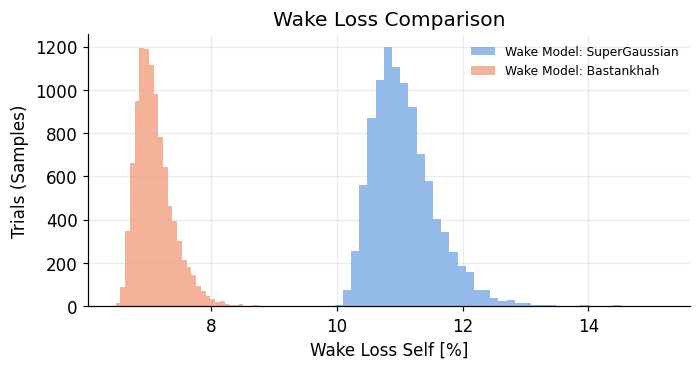

In [133]:
overlay_hist(final_s2_sg["loss_pct"], "Wake Model: SuperGaussian", COLOR_SG,
             final_s2_bk["loss_pct"], "Wake Model: Bastankhah", COLOR_BK,
             "Wake Loss Self [%]", "Trials (Samples)", "Wake Loss Comparison")

(<Figure size 715x385 with 1 Axes>,
 <Axes: title={'center': 'Model Divergence'}, xlabel='Simulation Year', ylabel='Wake Loss Self [%]'>)

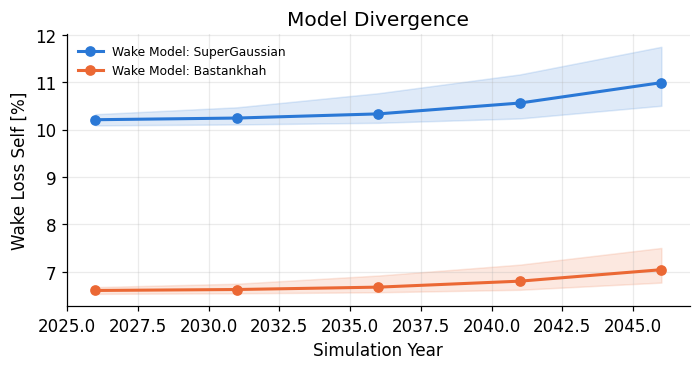

In [134]:
overlay_trajectory(segments_s2_sg, "Wake Model: SuperGaussian", COLOR_SG,
                    segments_s2_bk, "Wake Model: Bastankhah", COLOR_BK,
                    "Wake Loss Self [%]", "Model Divergence", value_col="loss_pct")

### Far-Wake Divergence Analysis

The relationship with capacity also remains positive in both models, but Super Gaussian continues to have a larger slope, approximately 0.000076 percentage points per MW compared with 0.000044 for Bastankhah. The difference is smaller than in Scenario 1 because Scenario 2 already starts under a high-loss condition, but the plots show that increasing capacity still comes with increasing wake loss and that Super Gaussian remains more sensitive to this growth.

In [135]:
p50_sg, p90_sg = np.percentile(final_s2_sg["loss_pct"], [50, 90])
p50_bk, p90_bk = np.percentile(final_s2_bk["loss_pct"], [50, 90])
{"P50_SuperGaussian": p50_sg, "P50_Bastankhah": p50_bk, "P50_delta": p50_sg - p50_bk,
  "P90_SuperGaussian": p90_sg, "P90_Bastankhah": p90_bk, "P90_delta": p90_sg - p90_bk}

{'P50_SuperGaussian': np.float64(10.992862808666034),
 'P50_Bastankhah': np.float64(7.045537921175754),
 'P50_delta': np.float64(3.9473248874902804),
 'P90_SuperGaussian': np.float64(11.748483118502172),
 'P90_Bastankhah': np.float64(7.504256170908113),
 'P90_delta': np.float64(4.244226947594059)}

In [136]:
# system sensitivity to distant/aggregate buildout: slope of Wake Loss Self against total active capacity, per model
slope_sg = np.polyfit(final_s2_sg["active_mw"], final_s2_sg["loss_pct"], 1)[0]
slope_bk = np.polyfit(final_s2_bk["active_mw"], final_s2_bk["loss_pct"], 1)[0]
{"slope_pct_per_MW_SuperGaussian": slope_sg, "slope_pct_per_MW_Bastankhah": slope_bk}

{'slope_pct_per_MW_SuperGaussian': np.float64(7.615295539797868e-05),
 'slope_pct_per_MW_Bastankhah': np.float64(4.410877786417265e-05)}

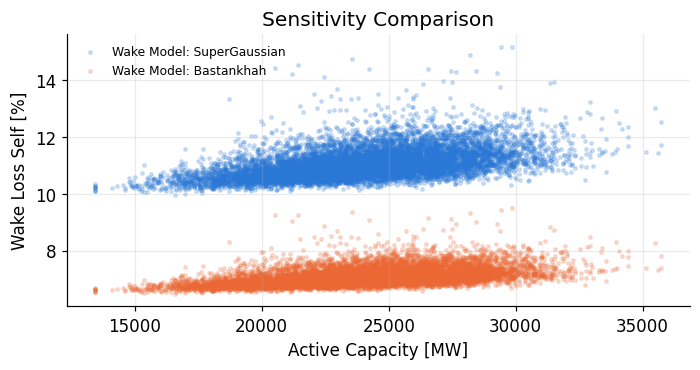

In [137]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.scatter(final_s2_sg["active_mw"], final_s2_sg["loss_pct"], s=5, alpha=0.2, color=COLOR_SG, label="Wake Model: SuperGaussian")
ax.scatter(final_s2_bk["active_mw"], final_s2_bk["loss_pct"], s=5, alpha=0.2, color=COLOR_BK, label="Wake Model: Bastankhah")
ax.set_xlabel("Active Capacity [MW]"); ax.set_ylabel("Wake Loss Self [%]"); ax.set_title("Sensitivity Comparison")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()